# Cervical Cancer Risk Factors – Mid-Term ML Project

**Dataset:** UCI Cervical Cancer (Risk Factors) — Hospital Universitario de Caracas  
**Task:** Binary classification — predict whether a patient has **cervical cancer** (Biopsy result: 0 = Negative, 1 = Positive)  
**Students:** Miled issa - Jad Maalouf - Edmond Ibllawi  
**Course:** CSIS 260
**Date:** April 2026

---

## Project Structure

| Section | Description |
|---------|-------------|
| 1 | Setup & Data Acquisition |
| 2 | Data Cleaning & Preparation |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Preprocessing & Scaling |
| 5 | Model Selection & Training |
| 6 | Model Evaluation & Comparison |
| 7 | L1 vs L2 Regularization Analysis |
| 8 | Summary & Observations |


## 1. Setup & Data Acquisition

**Goal of this section:** import all required libraries and load the Cervical Cancer dataset.

**Dataset facts:**
- **858 patients**, **36 features**, collected at Hospital Universitario de Caracas, Venezuela
- Features include demographics, sexual history, smoking habits, hormonal contraceptive use, IUD use, and STD history
- Target variable: **Biopsy** — the gold-standard diagnostic test (0 = Negative, 1 = Cancer Positive)
- The dataset contains **`?`-encoded missing values** that must be handled explicitly


In [1]:
# 1.1 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       learning_curve, StratifiedKFold)
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.neighbors         import NearestNeighbors
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.utils            import resample
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, confusion_matrix, classification_report,
                                       roc_auc_score, roc_curve, precision_recall_curve,
                                       average_precision_score)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


### 1.2 Load the dataset

**What we do here:**
- Load the CSV file using `pandas`, replacing `?` with `NaN` so Python recognises them as missing values.
- Display shape, column types, and a preview of the first rows.

In [2]:
# Load dataset — replace '?' with NaN (real missing values)
data = pd.read_csv("risk_factors_cervical_cancer.csv", na_values="?")

print(f"Shape: {data.shape[0]} rows × {data.shape[1]} columns")
print(f"\nColumn names:")
for col in data.columns:
    print(f"  • {col}")

Shape: 858 rows × 36 columns

Column names:
  • Age
  • Number of sexual partners
  • First sexual intercourse
  • Num of pregnancies
  • Smokes
  • Smokes (years)
  • Smokes (packs/year)
  • Hormonal Contraceptives
  • Hormonal Contraceptives (years)
  • IUD
  • IUD (years)
  • STDs
  • STDs (number)
  • STDs:condylomatosis
  • STDs:cervical condylomatosis
  • STDs:vaginal condylomatosis
  • STDs:vulvo-perineal condylomatosis
  • STDs:syphilis
  • STDs:pelvic inflammatory disease
  • STDs:genital herpes
  • STDs:molluscum contagiosum
  • STDs:AIDS
  • STDs:HIV
  • STDs:Hepatitis B
  • STDs:HPV
  • STDs: Number of diagnosis
  • STDs: Time since first diagnosis
  • STDs: Time since last diagnosis
  • Dx:Cancer
  • Dx:CIN
  • Dx:HPV
  • Dx
  • Hinselmann
  • Schiller
  • Citology
  • Biopsy


### 1.3 Initial dataset inspection

**What we do here:**
- Inspect data types and non-null counts.
- Check for missing values per column.
- Look at basic statistical summaries.
- Check for duplicate rows.

In [3]:
# Info about columns and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [4]:
# Missing values per column
data.isna().sum()

,0
Age,0
Number of sexual partners,26
First sexual intercourse,7
Num of pregnancies,56
Smokes,13
Smokes (years),13
Smokes (packs/year),13
Hormonal Contraceptives,108
Hormonal Contraceptives (years),108
IUD,117


In [5]:
# Statistical summary of numerical features
data.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.821,8.498,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.528,1.668,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995,2.803,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.276,1.447,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.146,0.353,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.220,4.089,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453,2.227,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641,0.480,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256,3.764,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112,0.316,0.0,0.0,0.0,0.0,1.0


In [6]:
# Duplicate rows
dup = data.duplicated().sum()
print(f"Number of duplicate rows: {dup}")

Number of duplicate rows: 23


**Observations:**
- The dataset has **858 rows and 36 columns**.
- All feature columns are numeric; `Biopsy` is the binary target.
- **26 features have missing values** encoded as `?`. The two time-since-diagnosis features are missing in **>91%** of rows.
- **23 duplicate rows** were found.
- Class imbalance is severe: **803 Negative (93.6%)** vs **55 Positive (6.4%)** — a **14.6:1 ratio**.


## 2. Data Cleaning & Preparation

**Goal of this section:** clean the dataset, handle missing values, remove irrelevant or leaky columns, and prepare the target variable.

**Steps:**
- Drop the two columns with >80% missing data (they would introduce noise, not signal).
- Remove three diagnostic-test columns (`Hinselmann`, `Schiller`, `Citology`) that constitute **target leakage** — they are other clinical tests, not risk factors.
- Audit and report remaining missing values.
- Display the final class balance.


In [7]:
# Drop columns with >80% missing data
HIGH_MISS = ["STDs: Time since first diagnosis", "STDs: Time since last diagnosis"]
data.drop(columns=HIGH_MISS, inplace=True)
print(f"Dropped high-miss columns: {HIGH_MISS}")

# Drop leaky diagnostic test columns
LEAKY = ["Hinselmann", "Schiller", "Citology"]
data.drop(columns=LEAKY, inplace=True)
print(f"Dropped leaky columns: {LEAKY}")

print(f"\nDataset shape after cleaning: {data.shape}")

Dropped high-miss columns: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
Dropped leaky columns: ['Hinselmann', 'Schiller', 'Citology']

Dataset shape after cleaning: (858, 31)


In [8]:
# Remaining missing values
miss = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
miss_remaining = miss[miss > 0]
print(f"Features still with missing data ({len(miss_remaining)}):")
print(miss_remaining.round(2).to_string())

Features still with missing data (24):
IUD (years)                           13.64
IUD                                   13.64
Hormonal Contraceptives (years)       12.59
Hormonal Contraceptives               12.59
STDs:condylomatosis                   12.24
STDs (number)                         12.24
STDs                                  12.24
STDs:cervical condylomatosis          12.24
STDs:AIDS                             12.24
STDs:molluscum contagiosum            12.24
STDs:genital herpes                   12.24
STDs:pelvic inflammatory disease      12.24
STDs:syphilis                         12.24
STDs:vulvo-perineal condylomatosis    12.24
STDs:vaginal condylomatosis           12.24
STDs:Hepatitis B                      12.24
STDs:HPV                              12.24
STDs:HIV                              12.24
Num of pregnancies                     6.53
Number of sexual partners              3.03
Smokes                                 1.52
Smokes (years)                       

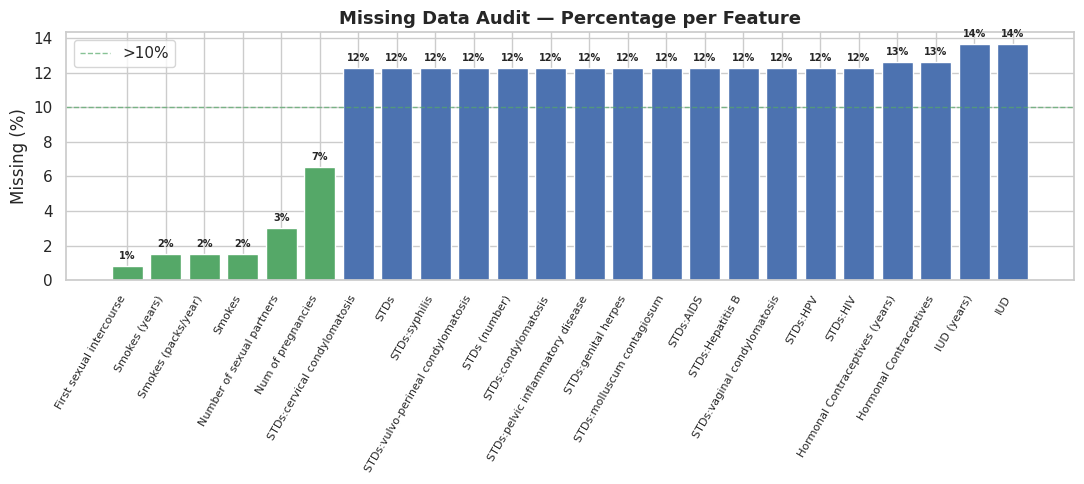

In [9]:
# Missing values visualization
miss_plot = miss[miss > 0].sort_values()
plt.figure(figsize=(11, 5))
colors = ["#C44E52" if v > 80 else "#4C72B0" if v > 10 else "#55A868" for v in miss_plot.values]
bars = plt.bar(miss_plot.index, miss_plot.values, color=colors, edgecolor="white")
plt.title("Missing Data Audit — Percentage per Feature", fontsize=13, fontweight="bold")
plt.ylabel("Missing (%)")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.axhline(10, color="#55A868", ls="--", lw=1.0, alpha=0.7, label=">10%")
for bar, v in zip(bars, miss_plot.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.0f}%",
             ha="center", va="bottom", fontsize=7, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Class distribution table
TARGET = "Biopsy"
counts = data[TARGET].value_counts()
pct    = (data[TARGET].value_counts(normalize=True)*100).round(2)
class_summary = pd.DataFrame({"Count": counts, "Percentage (%)": pct})
class_summary.index = ["Negative (0)", "Positive (1)"]
print("Class Balance:")
print(class_summary)
print(f"\nImbalance ratio: {counts[0]/counts[1]:.1f} : 1")

Class Balance:
              Count  Percentage (%)
Negative (0)    803           93.59
Positive (1)     55            6.41

Imbalance ratio: 14.6 : 1


## 3. Exploratory Data Analysis (EDA)

**Goal of this section:** understand the data structure, identify patterns, correlations, and feature relevance.

**We will produce:**
1. Target class distribution
2. Histograms of all continuous features
3. Feature distributions split by Biopsy class (KDE overlays)
4. Boxplots by diagnosis
5. Scatter plots (Age vs risk factors)
6. Pair plots
7. Full correlation heatmap
8. Target-correlation bar charts
9. STD and binary feature prevalence by class


### 3.1 Target distribution

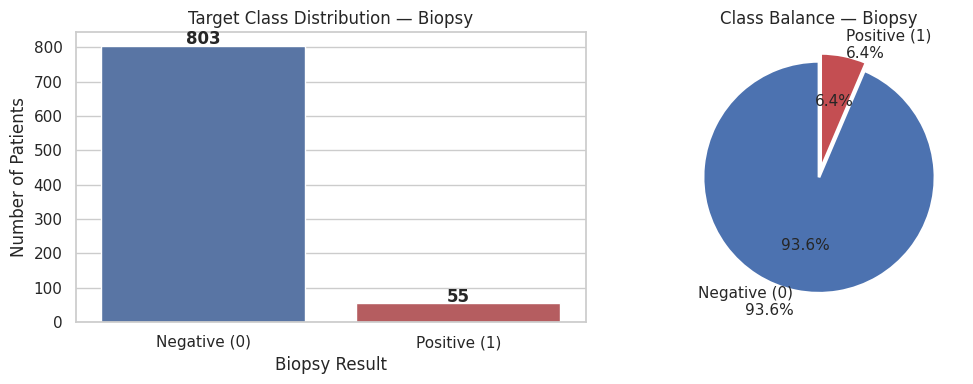

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Countplot
sns.countplot(x=TARGET, data=data, palette=["#4C72B0","#C44E52"], ax=axes[0])
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"])
axes[0].set_title("Target Class Distribution — Biopsy")
axes[0].set_xlabel("Biopsy Result"); axes[0].set_ylabel("Number of Patients")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha="center", fontsize=12, fontweight="bold")

# Pie chart
counts = data[TARGET].value_counts()
axes[1].pie(counts, labels=["Negative (0)\n93.6%","Positive (1)\n6.4%"],
            colors=["#4C72B0","#C44E52"],
            explode=[0, 0.07], startangle=90,
            autopct="%1.1f%%", textprops={"fontsize": 11},
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Class Balance — Biopsy")
plt.tight_layout()
plt.show()

**Observation:** The dataset is **highly imbalanced** — only 6.4% of patients have a positive biopsy.  
This is clinically realistic but makes recall the primary metric of interest.  
We will apply **oversampling** on the training set to compensate.


### 3.2 Histograms of continuous features

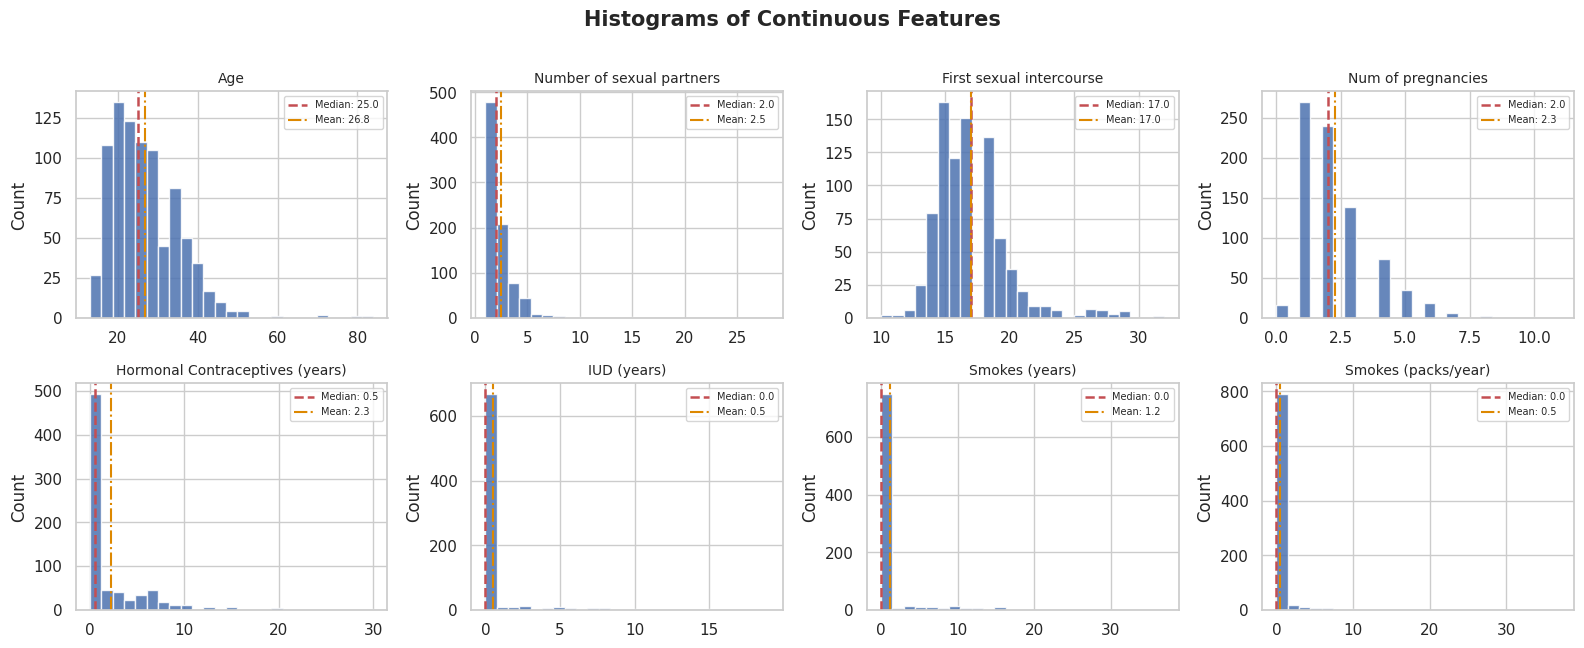

In [12]:
# Histograms — all continuous features
cont_features = ["Age", "Number of sexual partners", "First sexual intercourse",
                 "Num of pregnancies", "Hormonal Contraceptives (years)",
                 "IUD (years)", "Smokes (years)", "Smokes (packs/year)"]
cont_features = [c for c in cont_features if c in data.columns]

ncols = 4
nrows = (len(cont_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3.2))
axes_flat = axes.flatten()

for i, col in enumerate(cont_features):
    d = data[col].dropna()
    axes_flat[i].hist(d, bins=25, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes_flat[i].axvline(d.median(), color="#C44E52", ls="--", lw=1.8, label=f"Median: {d.median():.1f}")
    axes_flat[i].axvline(d.mean(),   color="#DD8800", ls="-.", lw=1.5, label=f"Mean: {d.mean():.1f}")
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_ylabel("Count")
    axes_flat[i].legend(fontsize=7)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Histograms of Continuous Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Feature distributions by Biopsy class (KDE overlays)

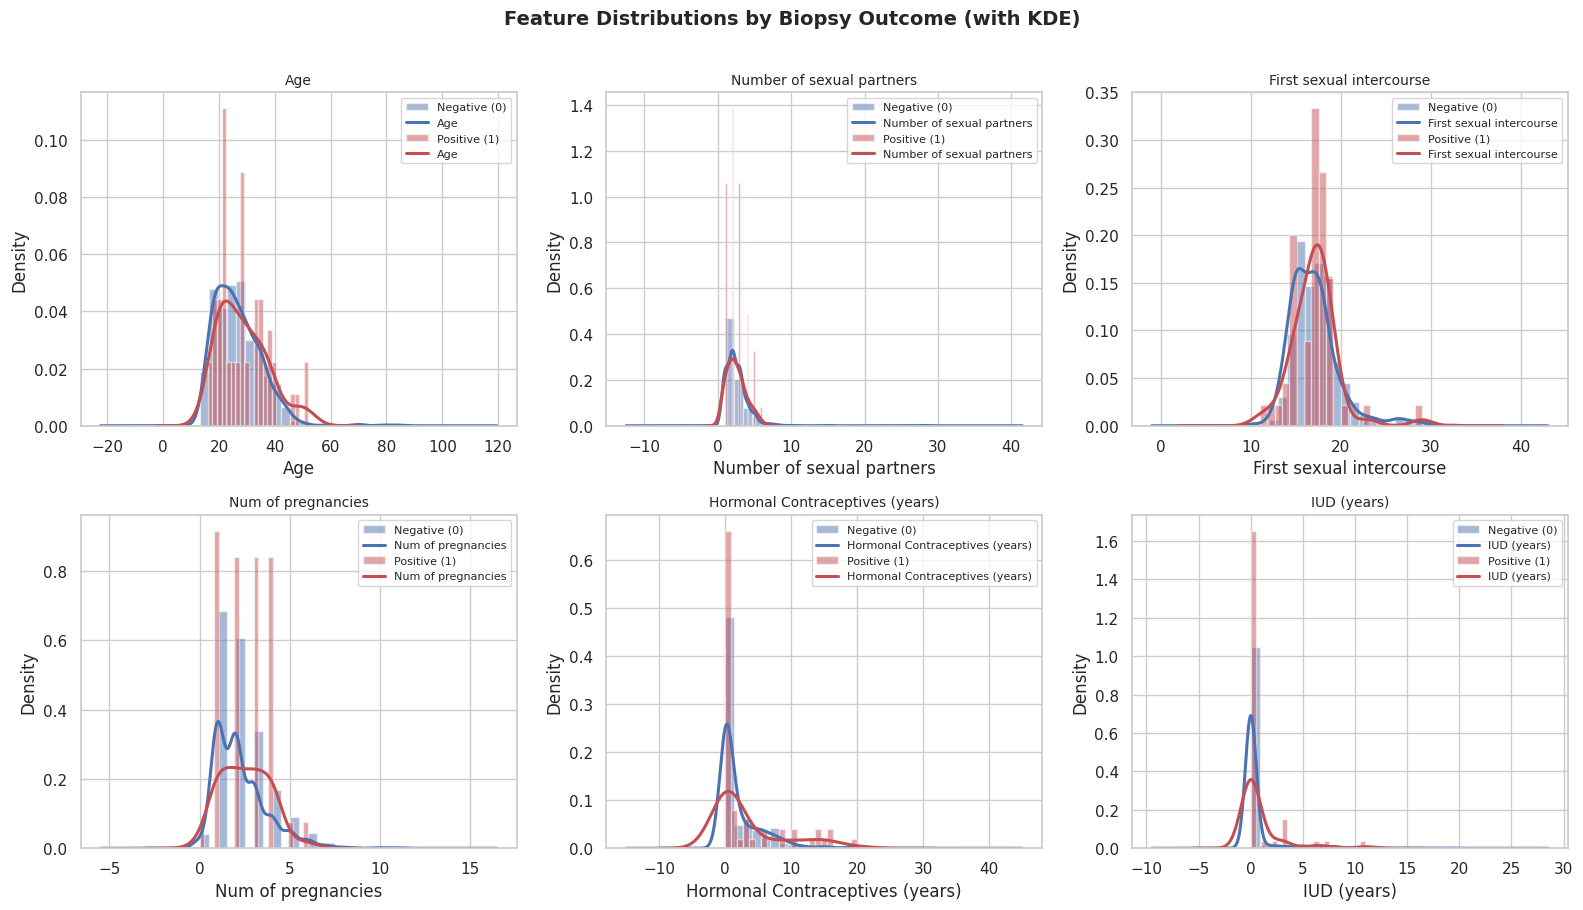

In [13]:
# Histograms split by Biopsy outcome — with KDE
plot_cols = ["Age", "Number of sexual partners", "First sexual intercourse",
             "Num of pregnancies", "Hormonal Contraceptives (years)", "IUD (years)"]
plot_cols = [c for c in plot_cols if c in data.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()
for i, col in enumerate(plot_cols):
    for bval, color, label in [(0,"#4C72B0","Negative (0)"), (1,"#C44E52","Positive (1)")]:
        subset = data[data[TARGET]==bval][col].dropna()
        axes_flat[i].hist(subset, bins=22, alpha=0.5, color=color, density=True,
                          edgecolor="white", label=label)
        subset.plot.kde(ax=axes_flat[i], color=color, linewidth=2.2)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_xlabel(col); axes_flat[i].set_ylabel("Density")
    axes_flat[i].legend(fontsize=8)

fig.suptitle("Feature Distributions by Biopsy Outcome (with KDE)", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Boxplots by diagnosis

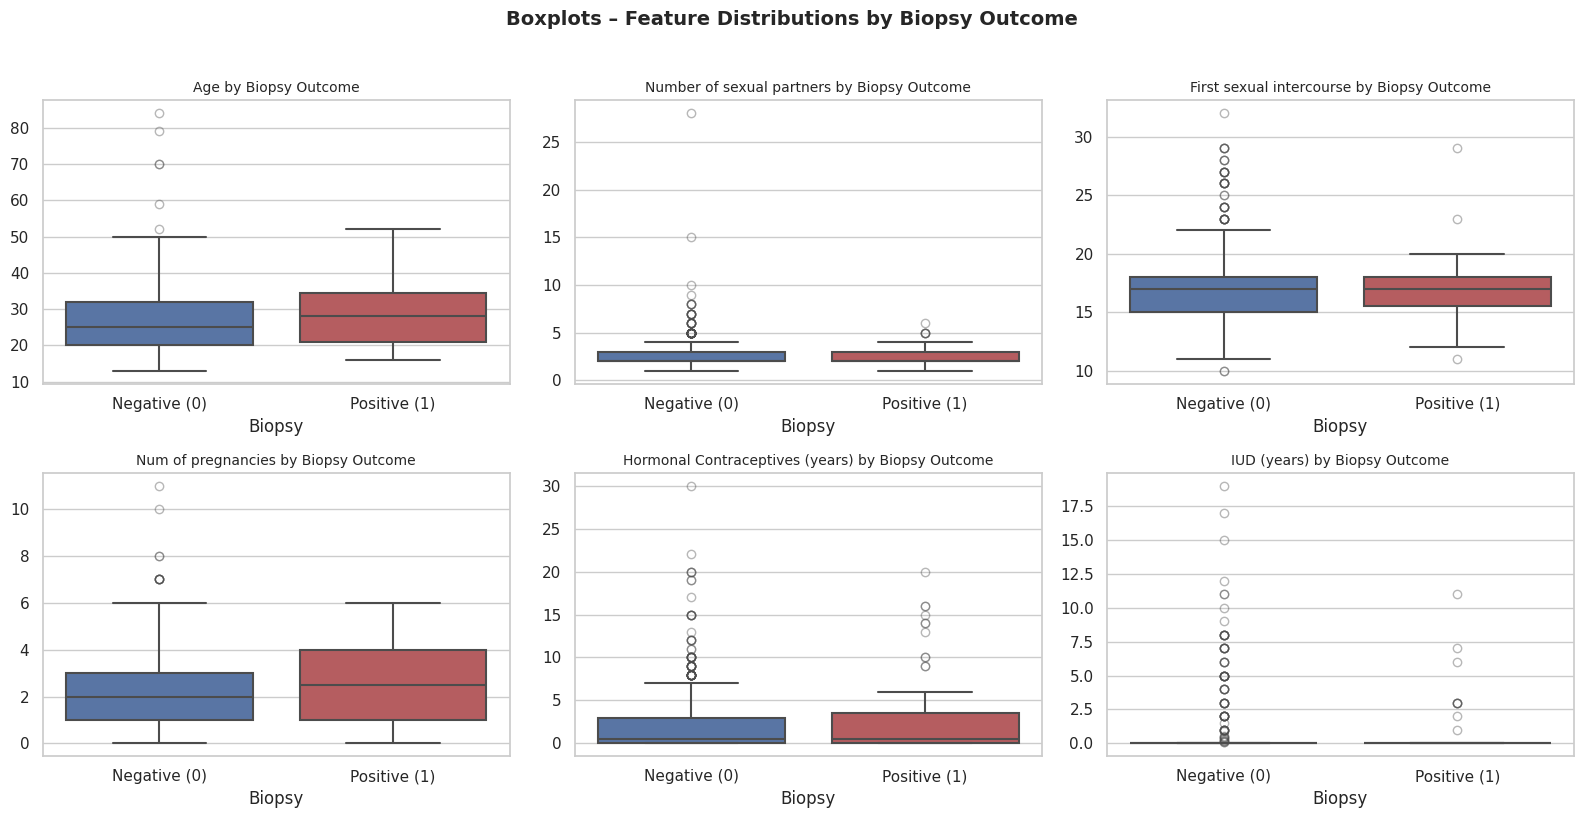

In [14]:
box_features = plot_cols.copy()

import math

n_features = len(box_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flatten()

for i, col in enumerate(box_features):
    sns.boxplot(
        x=TARGET,
        y=col,
        data=data,
        hue=TARGET,
        palette={0: "#4C72B0", 1: "#C44E52"},
        ax=axes_flat[i],
        linewidth=1.5,
        legend=False,
        flierprops={"alpha": 0.4}
    )
    axes_flat[i].set_xticklabels(["Negative (0)", "Positive (1)"])
    axes_flat[i].set_title(f"{col} by Biopsy Outcome", fontsize=10)
    axes_flat[i].set_xlabel("Biopsy")
    axes_flat[i].set_ylabel("")

# hide empty subplot spaces
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    "Boxplots – Feature Distributions by Biopsy Outcome",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### 3.5 Scatter Plots — Age vs Key Risk Factors

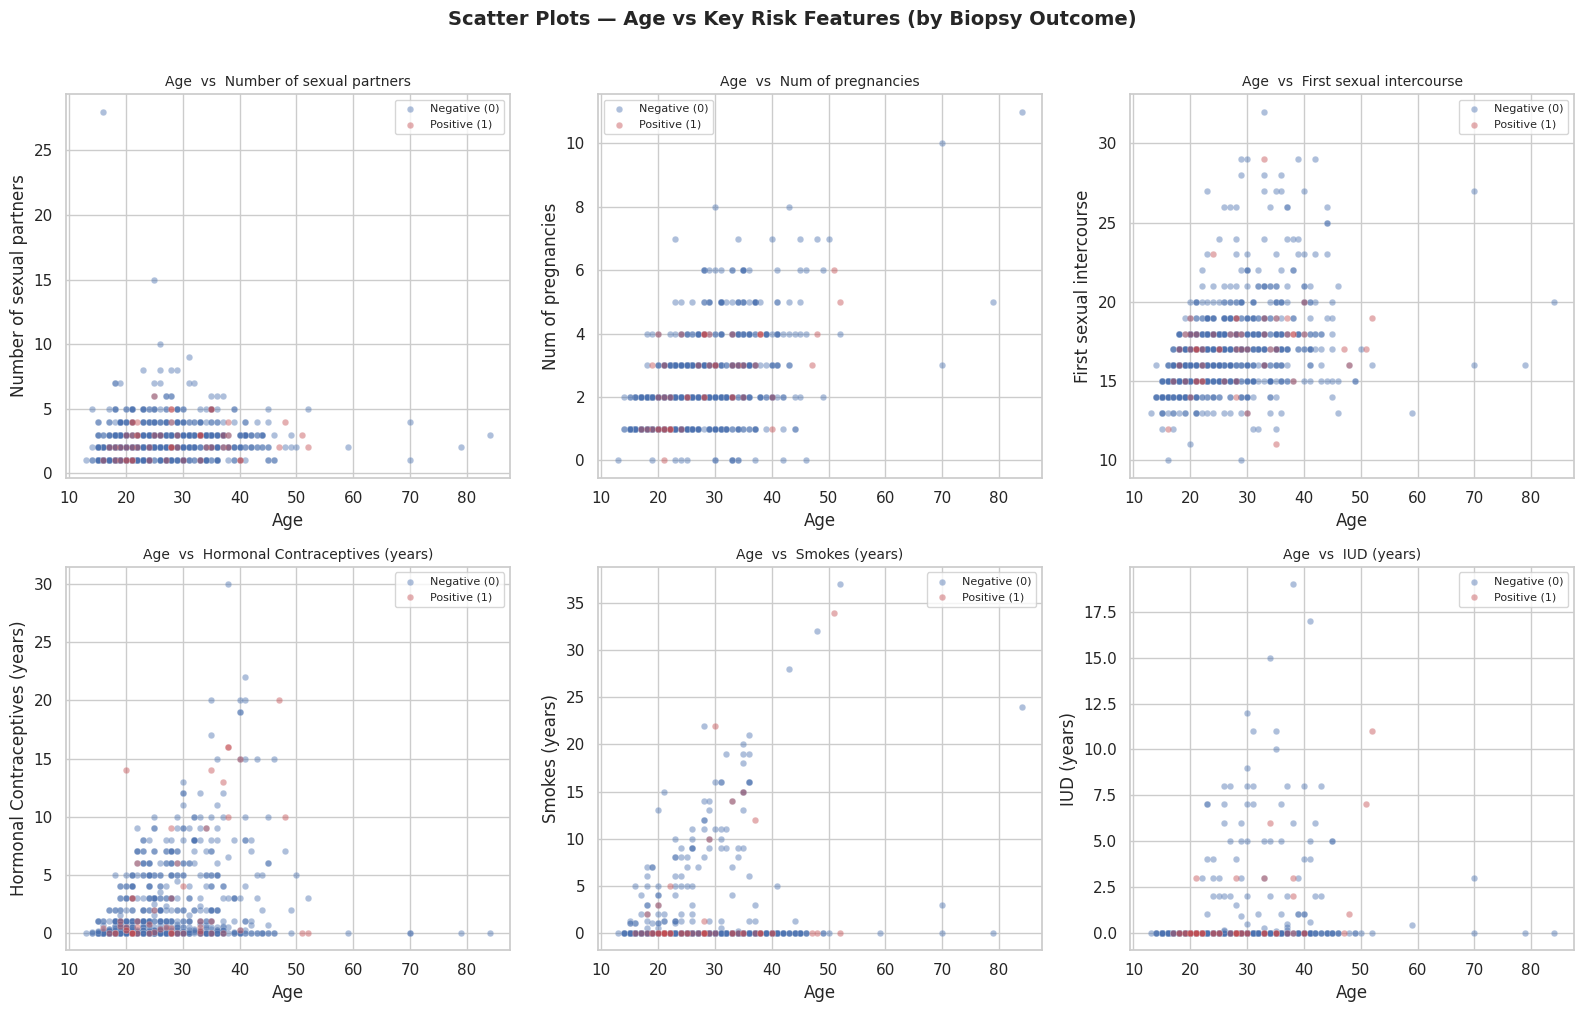

In [15]:
scatter_targets = ["Number of sexual partners", "Num of pregnancies",
                   "First sexual intercourse", "Hormonal Contraceptives (years)",
                   "Smokes (years)", "IUD (years)"]
scatter_targets = [c for c in scatter_targets if c in data.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()
for i, col in enumerate(scatter_targets):
    for bval, color, label in [(0,"#4C72B0","Negative (0)"), (1,"#C44E52","Positive (1)")]:
        subset = data[data[TARGET]==bval].dropna(subset=["Age", col])
        axes_flat[i].scatter(subset["Age"], subset[col],
                              alpha=0.45, s=22, color=color, label=label,
                              edgecolors="white", linewidths=0.2)
    axes_flat[i].set_xlabel("Age"); axes_flat[i].set_ylabel(col)
    axes_flat[i].set_title(f"Age  vs  {col}", fontsize=10)
    axes_flat[i].legend(fontsize=8)

fig.suptitle("Scatter Plots — Age vs Key Risk Features (by Biopsy Outcome)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.6 Pair Plot

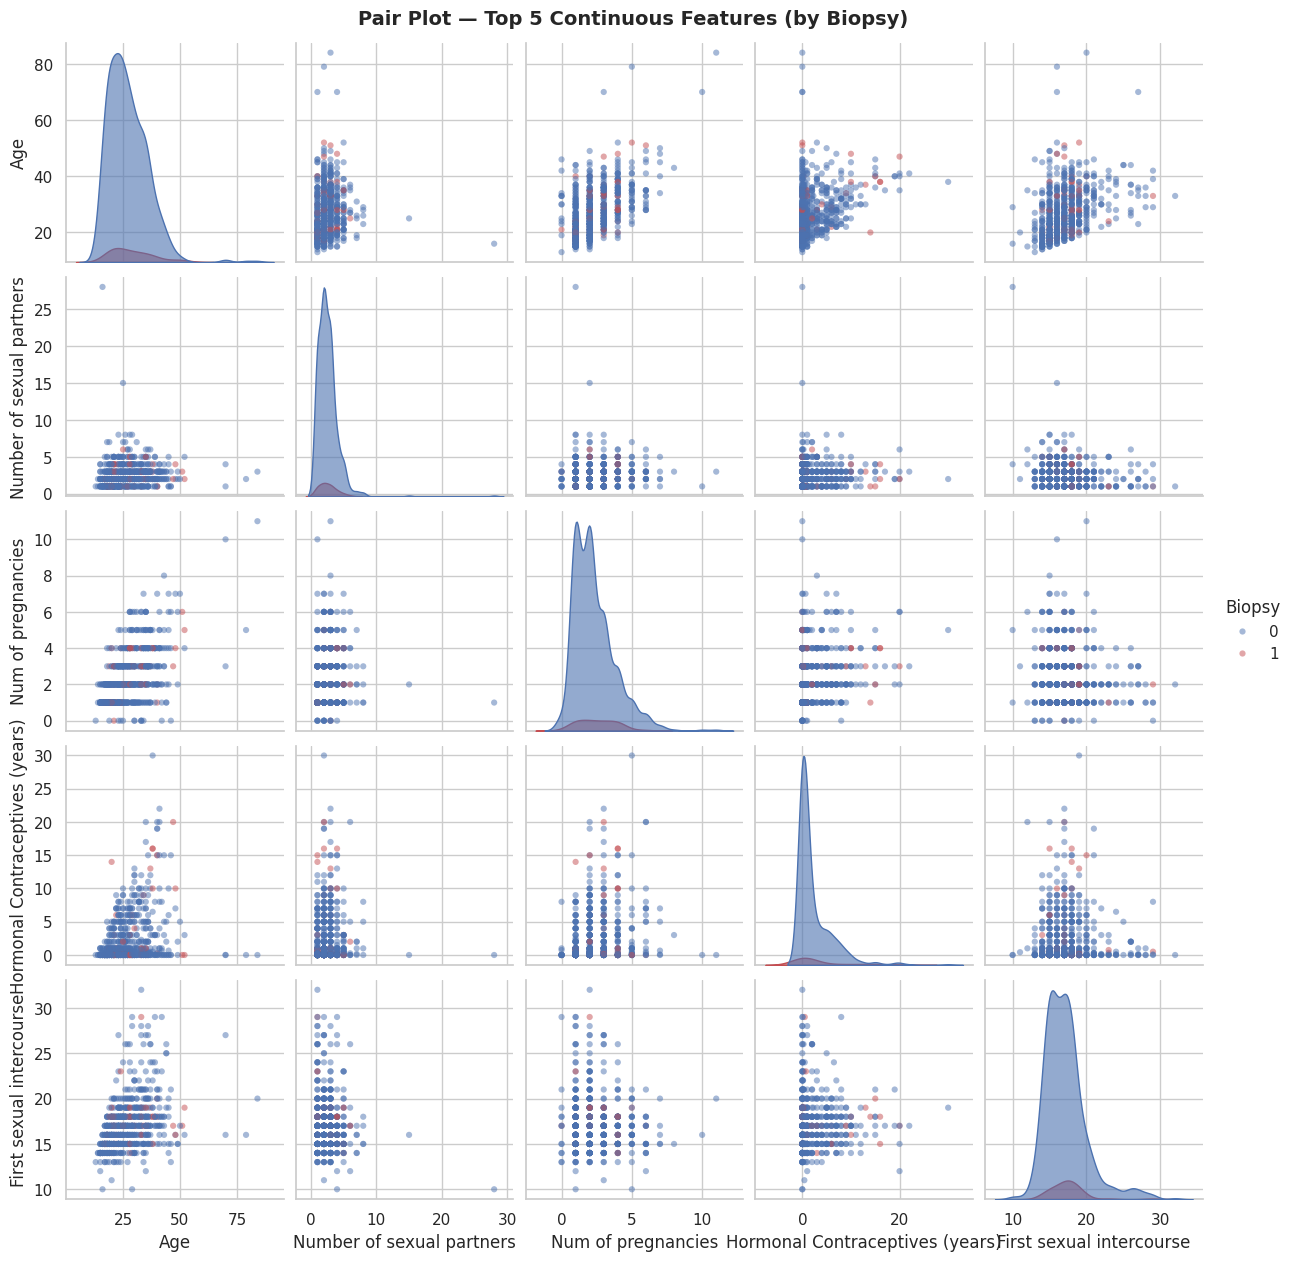

In [16]:
# Pair plot — top 5 continuous features
pair_cols = ["Age", "Number of sexual partners", "Num of pregnancies",
             "Hormonal Contraceptives (years)", "First sexual intercourse", TARGET]
pair_cols = [c for c in pair_cols if c in data.columns]

df_pair = data[pair_cols].dropna().copy()
df_pair[TARGET] = df_pair[TARGET].astype(str)

g = sns.pairplot(df_pair, hue=TARGET,
                 palette={"0":"#4C72B0","1":"#C44E52"},
                 plot_kws={"alpha":0.5,"s":20,"edgecolor":"none"},
                 diag_kws={"alpha":0.6}, corner=False)
g.figure.suptitle("Pair Plot — Top 5 Continuous Features (by Biopsy)",
                   y=1.01, fontsize=14, fontweight="bold")
plt.show()

### 3.7 Correlation Analysis

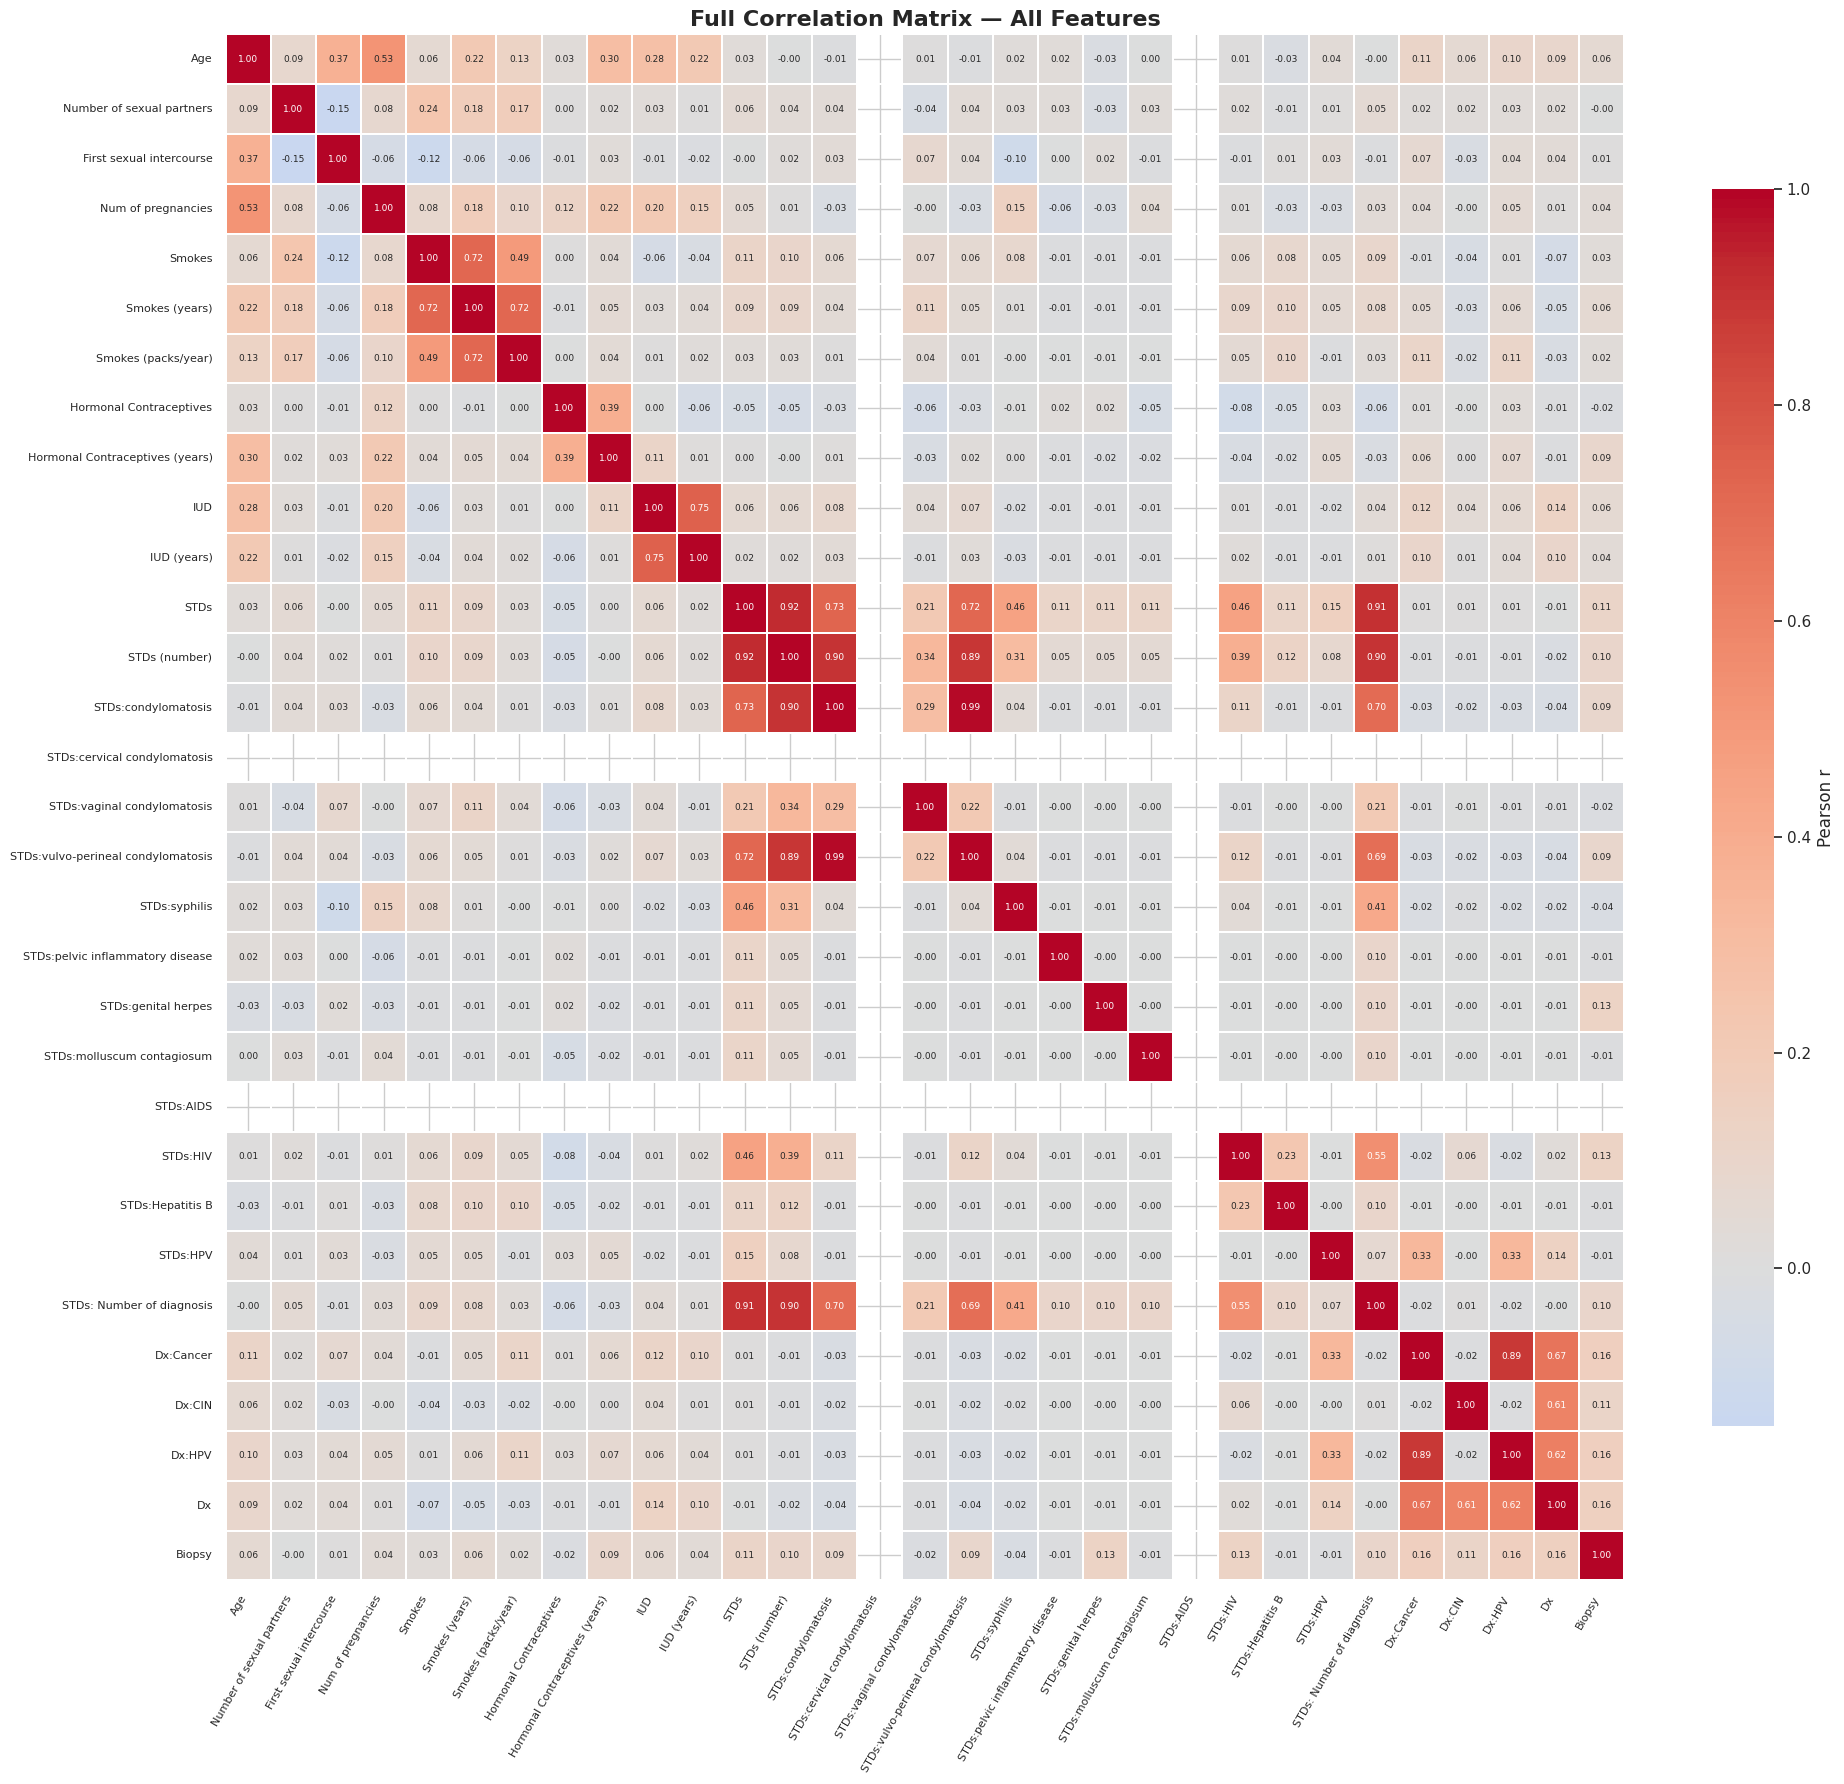

In [17]:
# Compute full correlation matrix (after median imputation)
num_df = data.select_dtypes(include=[np.number]).copy()
num_df_filled = num_df.fillna(num_df.median())
corr_matrix = num_df_filled.corr()

# Full heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0,
            linewidths=0.3, linecolor="white",
            annot=True, fmt=".2f",
            annot_kws={"size":6.5},
            cbar_kws={"shrink":0.8, "label":"Pearson r"})
plt.title("Full Correlation Matrix — All Features", fontsize=16, fontweight="bold")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Top 10 features positively correlated with Biopsy:
Dx:Cancer                          0.1609
Dx:HPV                             0.1609
Dx                                 0.1576
STDs:genital herpes                0.1305
STDs:HIV                           0.1277
STDs                               0.1141
Dx:CIN                             0.1132
STDs (number)                      0.1032
STDs: Number of diagnosis          0.0974
Hormonal Contraceptives (years)    0.0942


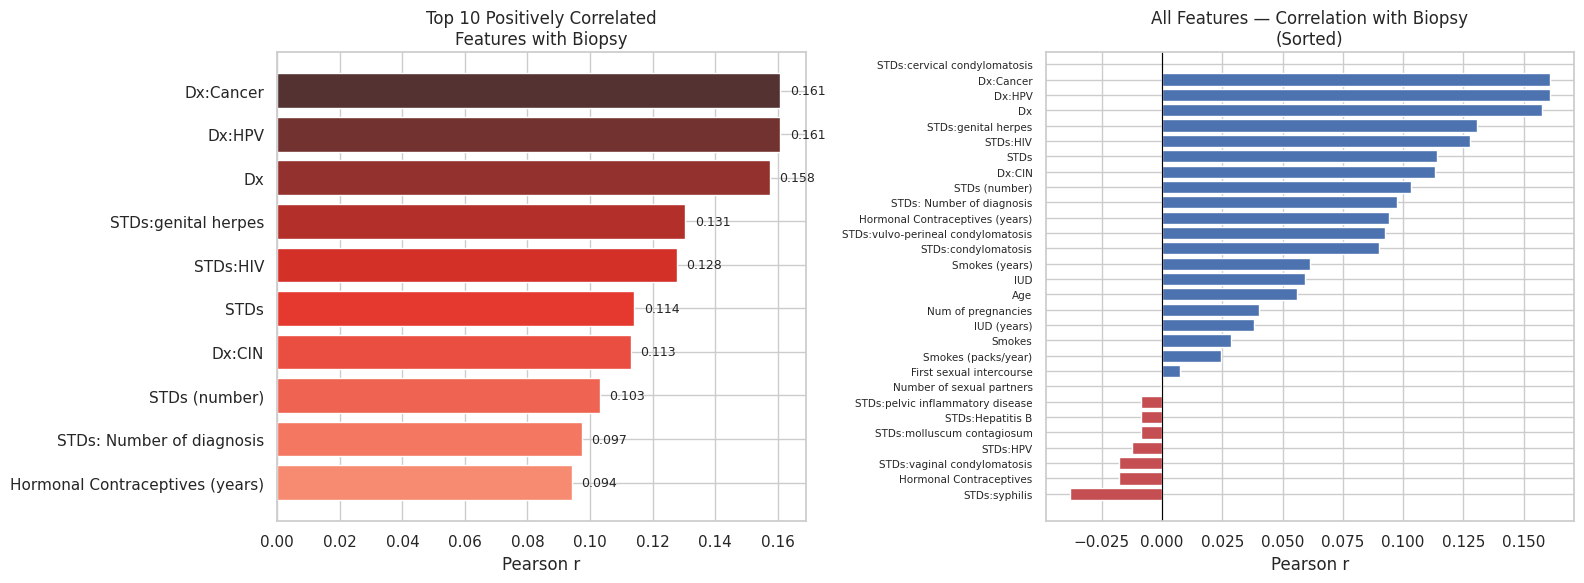

In [18]:
# Correlation with target variable
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
top10_pos = target_corr.head(10)
top10_all = target_corr.sort_values()

print("Top 10 features positively correlated with Biopsy:")
print(top10_pos.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 positive
axes[0].barh(top10_pos.index[::-1], top10_pos.values[::-1],
             color=sns.color_palette("Reds_d", 10), edgecolor="white")
axes[0].set_title("Top 10 Positively Correlated\nFeatures with Biopsy")
axes[0].set_xlabel("Pearson r")
for i, v in enumerate(top10_pos.values[::-1]):
    axes[0].text(v+0.003, i, f"{v:.3f}", va="center", fontsize=9)

# All features sorted
c_colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top10_all.values]
axes[1].barh(top10_all.index, top10_all.values, color=c_colors, edgecolor="white")
axes[1].set_title("All Features — Correlation with Biopsy\n(Sorted)")
axes[1].set_xlabel("Pearson r")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.show()

**Key Correlation Findings:**
- **`Dx:Cancer`, `Dx`, `Dx:HPV`, `Dx:CIN`** have the strongest positive correlations with Biopsy — these reflect prior cancer/HPV diagnoses, which are logically the strongest predictors.
- **`STDs:HIV`, `STDs:syphilis`** show moderate positive correlation — STD presence is a clinical risk factor.
- **`Age`** shows a small positive correlation — older age is a known epidemiological risk.
- No features show strong *negative* correlation with Biopsy.


### 3.8 Binary Features & STD Analysis

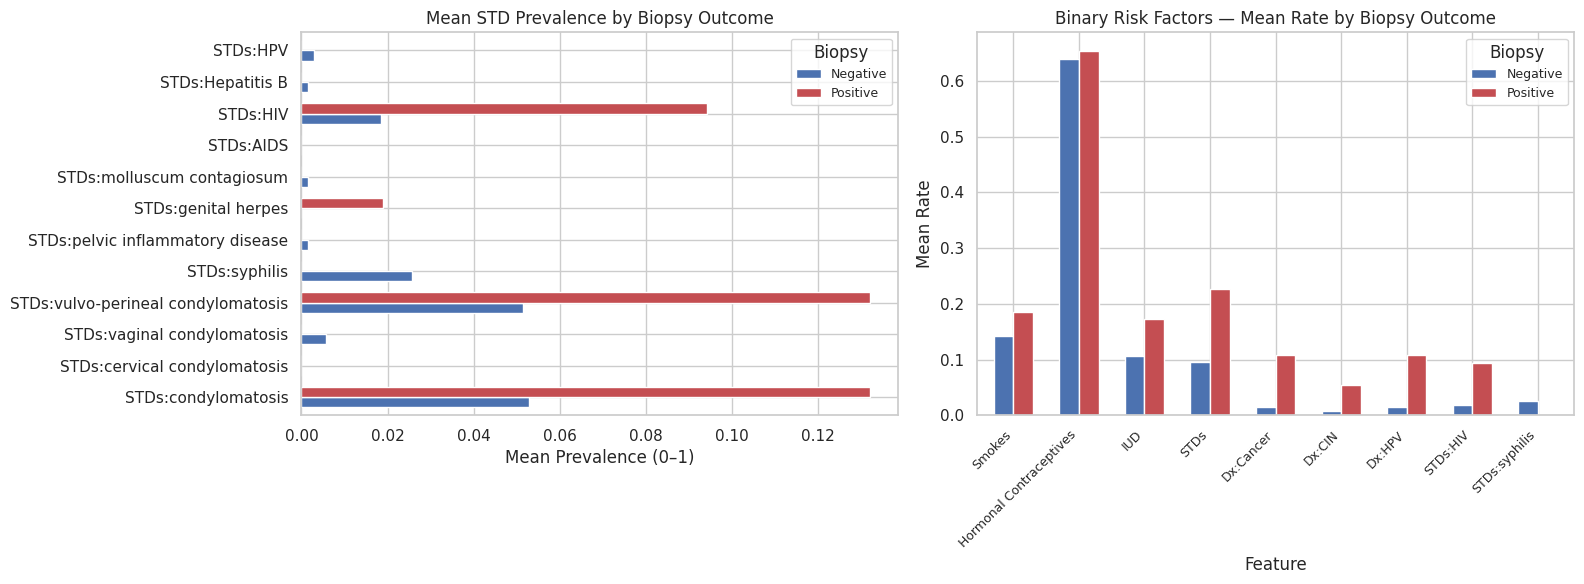

In [19]:
std_cols = [c for c in data.columns if c.startswith("STDs:") and data[c].nunique() <= 3]
std_prev = pd.DataFrame({
    col: {
        "Negative": data[data[TARGET]==0][col].mean(),
        "Positive": data[data[TARGET]==1][col].mean()
    } for col in std_cols
}).T

bin_features = ["Smokes","Hormonal Contraceptives","IUD","STDs",
                "Dx:Cancer","Dx:CIN","Dx:HPV","STDs:HIV","STDs:syphilis"]
bin_features = [c for c in bin_features if c in data.columns]
bin_prev = pd.DataFrame({
    col: {
        "Negative": data[data[TARGET]==0][col].mean(),
        "Positive": data[data[TARGET]==1][col].mean()
    } for col in bin_features
}).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
std_prev.plot.barh(ax=axes[0], color=["#4C72B0","#C44E52"], edgecolor="white", width=0.65)
axes[0].set_title("Mean STD Prevalence by Biopsy Outcome")
axes[0].set_xlabel("Mean Prevalence (0–1)")
axes[0].legend(title="Biopsy", fontsize=9)

bin_prev.plot.bar(ax=axes[1], color=["#4C72B0","#C44E52"], edgecolor="white", width=0.6)
axes[1].set_title("Binary Risk Factors — Mean Rate by Biopsy Outcome")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Mean Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=9)
axes[1].legend(title="Biopsy", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Scaling

**Goal of this section:** get the data ready for fair model training.

**What we do here:**
1. Split the data into **features** (`X`) and the **target** (`y`)
2. Use a **stratified 80/20 split** so the train and test sets keep the same class ratio
3. Handle class imbalance on the **training set only** with **SMOTE**
4. Fill the remaining missing values with **median imputation**
5. Scale numeric features with **StandardScaler**

> **Important:** all fitting steps are done on the **training data first** and then applied to the test data.  
> This helps prevent **data leakage** and keeps the evaluation honest.


In [20]:
# Separate features and target
FEATURES = [c for c in data.columns if c != TARGET]
X = data[FEATURES].copy()
y = data[TARGET].copy()

# Stratified 80/20 split
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train_raw.shape[0]} rows  —  Positive: {y_train_raw.sum():.0f} ({y_train_raw.mean()*100:.1f}%)")
print(f"Test  set: {X_test_raw.shape[0]} rows   —  Positive: {y_test.sum():.0f} ({y_test.mean()*100:.1f}%)")

Train set: 686 rows  —  Positive: 44 (6.4%)
Test  set: 172 rows   —  Positive: 11 (6.4%)


In [21]:
# Handle class imbalance — SMOTE (Synthetic Minority Oversampling Technique)
#
# SMOTE generates *new, interpolated* minority samples rather than duplicating
# the same 44 records over and over.  For each minority sample it finds its
# k nearest minority neighbours, then creates a synthetic point somewhere on
# the line segment between the sample and one of those neighbours.
# This gives the model a more varied view of what a positive patient looks like.
#
# Reference: Géron Ch. 3 — "Handling Skewed / Imbalanced Datasets".
# (imblearn not available in this environment → manual implementation below.)

def apply_smote(X_df, y_series, target, k_neighbors=5, random_state=42):
    rng      = np.random.RandomState(random_state)
    imp_tmp  = SimpleImputer(strategy="median")
    X_arr    = imp_tmp.fit_transform(X_df)          # work on imputed copy
    y_arr    = y_series.values.astype(int)

    X_min    = X_arr[y_arr == 1]
    n_needed = int((y_arr == 0).sum()) - len(X_min) # how many synthetics to create

    k        = min(k_neighbors, len(X_min) - 1)
    nbrs     = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    _, nn_ix = nbrs.kneighbors(X_min)               # shape (n_min, k+1)

    synthetic = []
    for _ in range(n_needed):
        i      = rng.randint(0, len(X_min))
        j      = nn_ix[i, rng.randint(1, k + 1)]   # skip index 0 (self)
        gap    = rng.random()
        synthetic.append(X_min[i] + gap * (X_min[j] - X_min[i]))

    X_syn     = np.array(synthetic)
    X_out     = np.vstack([X_arr, X_syn])
    y_out     = np.hstack([y_arr, np.ones(n_needed, dtype=int)])

    shuffle   = rng.permutation(len(X_out))
    return (pd.DataFrame(X_out[shuffle], columns=X_df.columns),
            pd.Series(y_out[shuffle], name=target))

X_train, y_train = apply_smote(X_train_raw, y_train_raw, TARGET)

print(f"SMOTE balanced train set : {len(X_train)} rows")
print(f"  Negative : {(y_train==0).sum()}  ({(y_train==0).mean()*100:.1f}%)")
print(f"  Positive : {(y_train==1).sum()}  ({(y_train==1).mean()*100:.1f}%)")


SMOTE balanced train set : 1284 rows
  Negative : 642  (50.0%)
  Positive : 642  (50.0%)


In [22]:
# Impute missing values (median strategy — robust to outliers)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test_raw)

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Verify: should be ~0 mean, ~1 std
scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
print("After StandardScaler — Training set statistics (first 5 features):")
print(scaled_df.describe().T.head(5)[["mean","std"]].round(4))

After StandardScaler — Training set statistics (first 5 features):
                           mean     std
Age                         0.0  1.0004
Number of sexual partners  -0.0  1.0004
First sexual intercourse   -0.0  1.0004
Num of pregnancies         -0.0  1.0004
Smokes                      0.0  1.0004


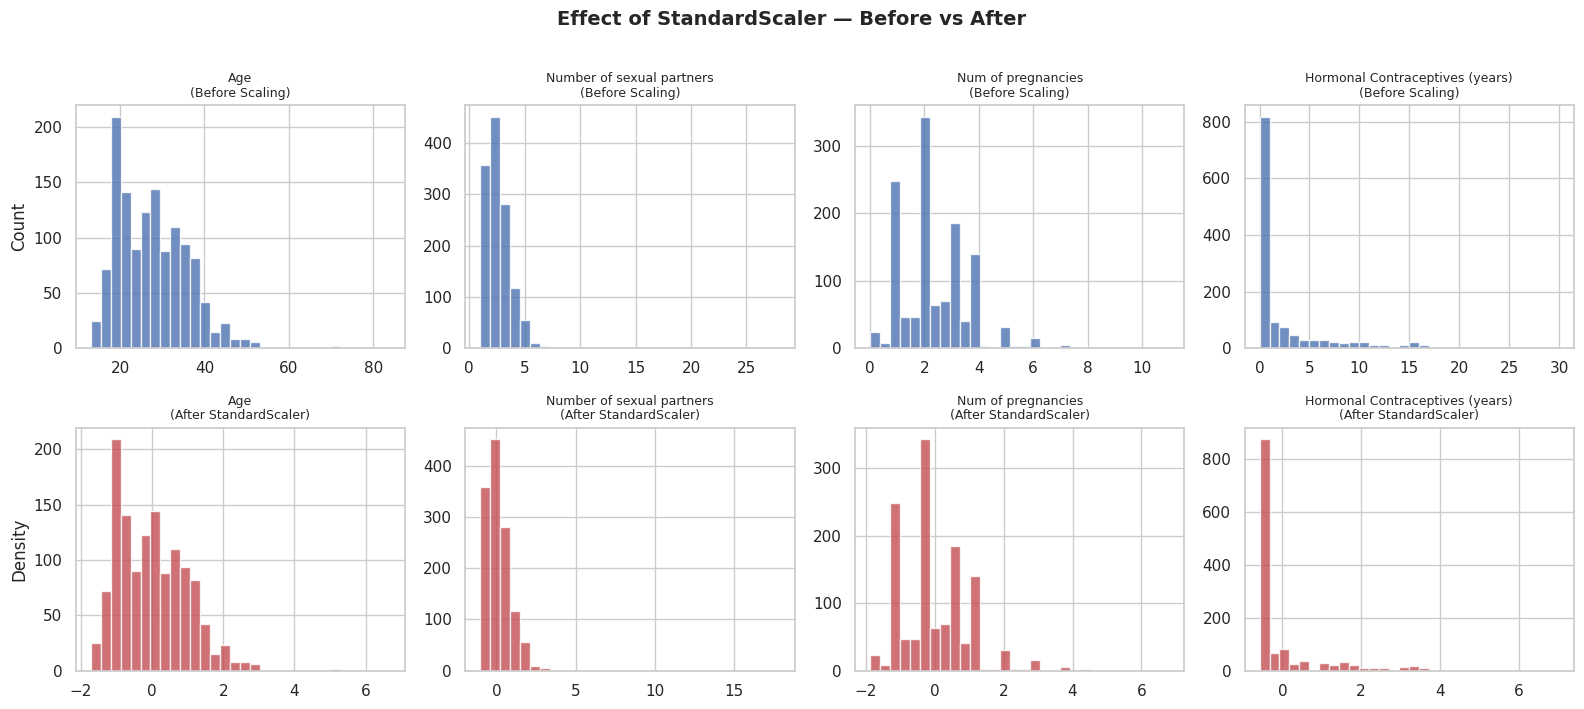

In [23]:
# Scaling effect visualization
cols_show = ["Age", "Number of sexual partners", "Num of pregnancies",
             "Hormonal Contraceptives (years)"]
col_idxs  = [FEATURES.index(c) for c in cols_show]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, (col, idx) in enumerate(zip(cols_show, col_idxs)):
    raw_vals = X_train_imp[:, idx]
    scl_vals = X_train_scaled[:, idx]
    axes[0][j].hist(raw_vals, bins=30, color="#4C72B0", edgecolor="white", alpha=0.8)
    axes[0][j].set_title(f"{col}\n(Before Scaling)", fontsize=9)
    axes[0][j].set_ylabel("Count" if j==0 else "")
    axes[1][j].hist(scl_vals, bins=30, color="#C44E52", edgecolor="white", alpha=0.8)
    axes[1][j].set_title(f"{col}\n(After StandardScaler)", fontsize=9)
    axes[1][j].set_ylabel("Density" if j==0 else "")
fig.suptitle("Effect of StandardScaler — Before vs After", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Model Selection and Training

**Goal of this section:** compare a small set of strong baseline models without adding hyperparameter tuning.

**Models used:**

| Model | Regularization / Control | Why it is included |
|-------|---------------------------|--------------------|
| Logistic Regression (L2) | **L2 / Ridge** | Strong, explainable baseline |
| Logistic Regression (L1) | **L1 / Lasso** | Baseline with built-in feature selection |
| SVM (RBF kernel) | `C`, `gamma` | Flexible non-linear model |
| Random Forest | depth / trees / leaf size | Robust ensemble baseline |
| Decision Tree | `max_depth` | Simple interpretable benchmark |

> All models are trained on the **SMOTE-balanced training set** after **median imputation** and **scaling**.  
> The settings are kept fixed on purpose so the comparison stays simple and easy to explain.


### 5.1 Logistic Regression (L2 regularization)

In [24]:
log_reg_l2 = LogisticRegression(
    penalty="l2", C=1.0, solver="lbfgs",
    max_iter=2000, class_weight="balanced", random_state=42
)
log_reg_l2.fit(X_train_scaled, y_train)
print("LogReg L2 trained. Non-zero coefs:", np.sum(log_reg_l2.coef_[0] != 0))

LogReg L2 trained. Non-zero coefs: 27


### 5.2 Logistic Regression (L1 regularization)

In [25]:
log_reg_l1 = LogisticRegression(
    penalty="l1", C=0.5, solver="liblinear",
    max_iter=2000, class_weight="balanced", random_state=42
)
log_reg_l1.fit(X_train_scaled, y_train)
print("LogReg L1 trained. Non-zero coefs:", np.sum(log_reg_l1.coef_[0] != 0))

LogReg L1 trained. Non-zero coefs: 24


### 5.3 Support Vector Machine (RBF kernel)

In [26]:
svm_clf = SVC(
    kernel="rbf", C=10, gamma="scale",
    probability=True, class_weight="balanced", random_state=42
)
svm_clf.fit(X_train_scaled, y_train)
print("SVM RBF trained.")

SVM RBF trained.


### 5.4 Random Forest Classifier

In [27]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=3,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_scaled, y_train)
print("Random Forest trained.")

Random Forest trained.


### 5.5 Decision Tree Classifier

In [28]:
dt_clf = DecisionTreeClassifier(
    max_depth=6, class_weight="balanced", random_state=42
)
dt_clf.fit(X_train_scaled, y_train)
print("Decision Tree trained.")

Decision Tree trained.


## 6. Model Evaluation and Comparison

**Goal of this section:** compare the models with metrics that make sense for an **imbalanced medical classification problem**.

**Main metrics:**
- **Accuracy** — overall correct predictions
- **Precision** — when the model predicts positive, how often it is right
- **Recall / Sensitivity** — how many real positive cases the model catches
- **F1-score** — balance between precision and recall
- **ROC-AUC** — overall class-separation ability across thresholds

**What we also do here:**
- Use the model's **probability scores**
- Apply **threshold tuning** instead of relying only on the default 0.50 cutoff
- Review **confusion matrices**, **ROC curves**, and **Precision–Recall curves**

> **Clinical priority:** in cancer screening, **Recall** matters a lot because a **false negative** means missing a patient who may need follow-up.


### 6.1 Evaluation helper function

In [29]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te,
                   X_raw=None, y_raw=None):
    """Compute metrics with threshold tuning + CV, plot confusion matrix."""
    y_pred_train = model.predict(X_tr)
    y_prob_test  = model.predict_proba(X_te)[:, 1]

    # ── 1. Threshold tuning ──────────────────────────────────────────────────
    # Sweep thresholds from 0.10 to 0.55, pick the one that maximises recall
    # while keeping F1 ≥ 0.13 (avoids collapsing precision to near-zero).
    # In cancer screening a missed case is far costlier than a false alarm,
    # so we deliberately lower the bar the model needs to say "positive".
    best_t, best_rec = 0.50, recall_score(y_te,
                            (y_prob_test >= 0.50).astype(int), zero_division=0)
    for t in np.arange(0.10, 0.55, 0.01):
        preds_t = (y_prob_test >= t).astype(int)
        r = recall_score(y_te, preds_t, zero_division=0)
        f = f1_score(y_te, preds_t, zero_division=0)
        if f >= 0.13 and r > best_rec:
            best_rec, best_t = r, round(t, 2)

    y_pred_test = (y_prob_test >= best_t).astype(int)

    metrics = {
        "Model":      name,
        "Train Acc":  accuracy_score(y_tr, y_pred_train),
        "Test Acc":   accuracy_score(y_te, y_pred_test),
        "Precision":  precision_score(y_te, y_pred_test, zero_division=0),
        "Recall":     recall_score(y_te, y_pred_test, zero_division=0),
        "F1-Score":   f1_score(y_te, y_pred_test, zero_division=0),
        "AUC-ROC":    roc_auc_score(y_te, y_prob_test),
        "y_pred": y_pred_test, "y_prob": y_prob_test,
    }

    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  Threshold (tuned)  : {best_t:.2f}  (default was 0.50)")
    print(f"  Train Accuracy     : {metrics['Train Acc']:.4f}")
    print(f"  Test  Accuracy     : {metrics['Test Acc']:.4f}")
    print(f"  Precision          : {metrics['Precision']:.4f}")
    print(f"  Recall             : {metrics['Recall']:.4f}")
    print(f"  F1-Score           : {metrics['F1-Score']:.4f}")
    print(f"  AUC-ROC            : {metrics['AUC-ROC']:.4f}")

    # ── 2. Stratified K-Fold cross-validation ────────────────────────────────
    # Runs on the *raw* (un-oversampled) training split so folds are honest.
    # The full impute → scale → fit pipeline is re-run inside each fold to
    # prevent any leakage of scale or imputation statistics across folds.
    if X_raw is not None and y_raw is not None:
        skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf",     model),
        ])
        cv_r  = cross_val_score(pipe, X_raw, y_raw, cv=skf, scoring="recall")
        cv_f1 = cross_val_score(pipe, X_raw, y_raw, cv=skf, scoring="f1")
        cv_au = cross_val_score(pipe, X_raw, y_raw, cv=skf, scoring="roc_auc")
        print(f"\n  5-Fold CV (stratified, raw train split):")
        print(f"    Recall  : {cv_r.mean():.4f} ± {cv_r.std():.4f}  "
              f"folds={np.round(cv_r, 3)}")
        print(f"    F1      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
        print(f"    AUC-ROC : {cv_au.mean():.4f} ± {cv_au.std():.4f}")
        metrics["CV Recall"] = round(cv_r.mean(), 4)
        metrics["CV F1"]     = round(cv_f1.mean(), 4)
        metrics["CV AUC"]    = round(cv_au.mean(), 4)

    print(f"\nClassification Report (Test Set — threshold {best_t:.2f}):")
    print(classification_report(y_te, y_pred_test,
                                 target_names=["Negative (0)", "Positive (1)"],
                                 digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred_test)
    tn, fp, fn, tp = cm.ravel()
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Neg (0)", "Pos (1)"],
                yticklabels=["Neg (0)", "Pos (1)"],
                linewidths=1, linecolor="white", cbar=False,
                annot_kws={"size": 13, "weight": "bold"})
    plt.title(f"Confusion Matrix — {name}\n"
              f"Sensitivity: {tp/(tp+fn+1e-9):.2%}   Specificity: {tn/(tn+fp+1e-9):.2%}")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return metrics

print("Helper function defined.")


Helper function defined.


### 6.2 Evaluate all models


  LogReg L2
  Threshold (tuned)  : 0.23  (default was 0.50)
  Train Accuracy     : 0.7445
  Test  Accuracy     : 0.1512
  Precision          : 0.0701
  Recall             : 1.0000
  F1-Score           : 0.1310
  AUC-ROC            : 0.6335

  5-Fold CV (stratified, raw train split):
    Recall  : 0.4500 ± 0.1495  folds=[0.667 0.25  0.444 0.556 0.333]
    F1      : 0.2198 ± 0.0566
    AUC-ROC : 0.6173 ± 0.0869

Classification Report (Test Set — threshold 0.23):
              precision    recall  f1-score   support

Negative (0)     1.0000    0.0932    0.1705       161
Positive (1)     0.0701    1.0000    0.1310        11

    accuracy                         0.1512       172
   macro avg     0.5350    0.5466    0.1507       172
weighted avg     0.9405    0.1512    0.1679       172



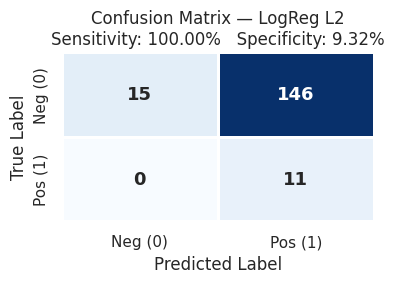


  LogReg L1
  Threshold (tuned)  : 0.24  (default was 0.50)
  Train Accuracy     : 0.7461
  Test  Accuracy     : 0.1628
  Precision          : 0.0710
  Recall             : 1.0000
  F1-Score           : 0.1325
  AUC-ROC            : 0.6431

  5-Fold CV (stratified, raw train split):
    Recall  : 0.4750 ± 0.1218  folds=[0.667 0.375 0.556 0.444 0.333]
    F1      : 0.2288 ± 0.0482
    AUC-ROC : 0.6740 ± 0.0551

Classification Report (Test Set — threshold 0.24):
              precision    recall  f1-score   support

Negative (0)     1.0000    0.1056    0.1910       161
Positive (1)     0.0710    1.0000    0.1325        11

    accuracy                         0.1628       172
   macro avg     0.5355    0.5528    0.1618       172
weighted avg     0.9406    0.1628    0.1873       172



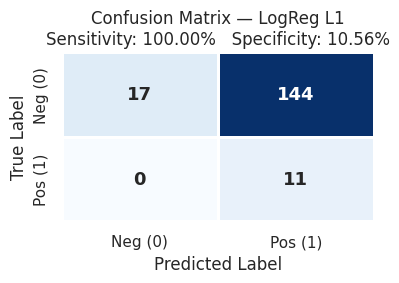


  SVM RBF
  Threshold (tuned)  : 0.10  (default was 0.50)
  Train Accuracy     : 0.9058
  Test  Accuracy     : 0.4593
  Precision          : 0.0816
  Recall             : 0.7273
  F1-Score           : 0.1468
  AUC-ROC            : 0.6262

  5-Fold CV (stratified, raw train split):
    Recall  : 0.1833 ± 0.0598  folds=[0.222 0.25  0.222 0.111 0.111]
    F1      : 0.1569 ± 0.0445
    AUC-ROC : 0.5942 ± 0.0350

Classification Report (Test Set — threshold 0.10):
              precision    recall  f1-score   support

Negative (0)     0.9595    0.4410    0.6043       161
Positive (1)     0.0816    0.7273    0.1468        11

    accuracy                         0.4593       172
   macro avg     0.5205    0.5841    0.3755       172
weighted avg     0.9033    0.4593    0.5750       172



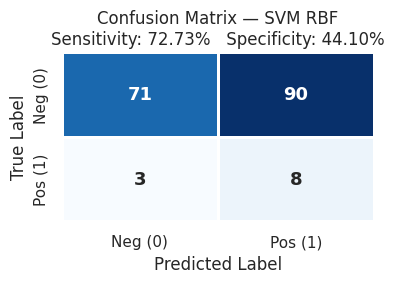


  Random Forest
  Threshold (tuned)  : 0.10  (default was 0.50)
  Train Accuracy     : 0.9556
  Test  Accuracy     : 0.2267
  Precision          : 0.0764
  Recall             : 1.0000
  F1-Score           : 0.1419
  AUC-ROC            : 0.6527

  5-Fold CV (stratified, raw train split):
    Recall  : 0.1333 ± 0.1633  folds=[0.444 0.    0.111 0.111 0.   ]
    F1      : 0.1521 ± 0.1836
    AUC-ROC : 0.6657 ± 0.0573

Classification Report (Test Set — threshold 0.10):
              precision    recall  f1-score   support

Negative (0)     1.0000    0.1739    0.2963       161
Positive (1)     0.0764    1.0000    0.1419        11

    accuracy                         0.2267       172
   macro avg     0.5382    0.5870    0.2191       172
weighted avg     0.9409    0.2267    0.2864       172



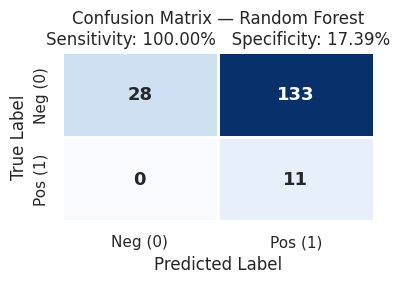


  Decision Tree
  Threshold (tuned)  : 0.10  (default was 0.50)
  Train Accuracy     : 0.8715
  Test  Accuracy     : 0.4070
  Precision          : 0.0826
  Recall             : 0.8182
  F1-Score           : 0.1500
  AUC-ROC            : 0.5951

  5-Fold CV (stratified, raw train split):
    Recall  : 0.2667 ± 0.1507  folds=[0.444 0.    0.333 0.333 0.222]
    F1      : 0.1427 ± 0.0831
    AUC-ROC : 0.4993 ± 0.1387

Classification Report (Test Set — threshold 0.10):
              precision    recall  f1-score   support

Negative (0)     0.9683    0.3789    0.5446       161
Positive (1)     0.0826    0.8182    0.1500        11

    accuracy                         0.4070       172
   macro avg     0.5254    0.5985    0.3473       172
weighted avg     0.9116    0.4070    0.5194       172



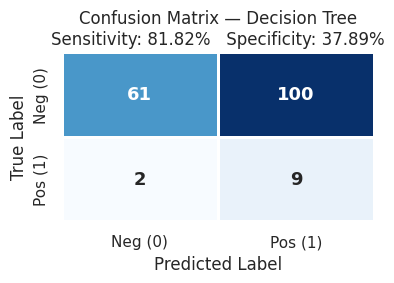



Final Results Summary:
        Model  Train Acc  Test Acc  Precision  Recall  F1-Score  AUC-ROC
    LogReg L2     0.7445    0.1512     0.0701  1.0000    0.1310   0.6335
    LogReg L1     0.7461    0.1628     0.0710  1.0000    0.1325   0.6431
      SVM RBF     0.9058    0.4593     0.0816  0.7273    0.1468   0.6262
Random Forest     0.9556    0.2267     0.0764  1.0000    0.1419   0.6527
Decision Tree     0.8715    0.4070     0.0826  0.8182    0.1500   0.5951


,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,AUC-ROC
0,LogReg L2,0.7445,0.1512,0.0701,1.0000,0.1310,0.6335
1,LogReg L1,0.7461,0.1628,0.0710,1.0000,0.1325,0.6431
2,SVM RBF,0.9058,0.4593,0.0816,0.7273,0.1468,0.6262
3,Random Forest,0.9556,0.2267,0.0764,1.0000,0.1419,0.6527
4,Decision Tree,0.8715,0.4070,0.0826,0.8182,0.1500,0.5951


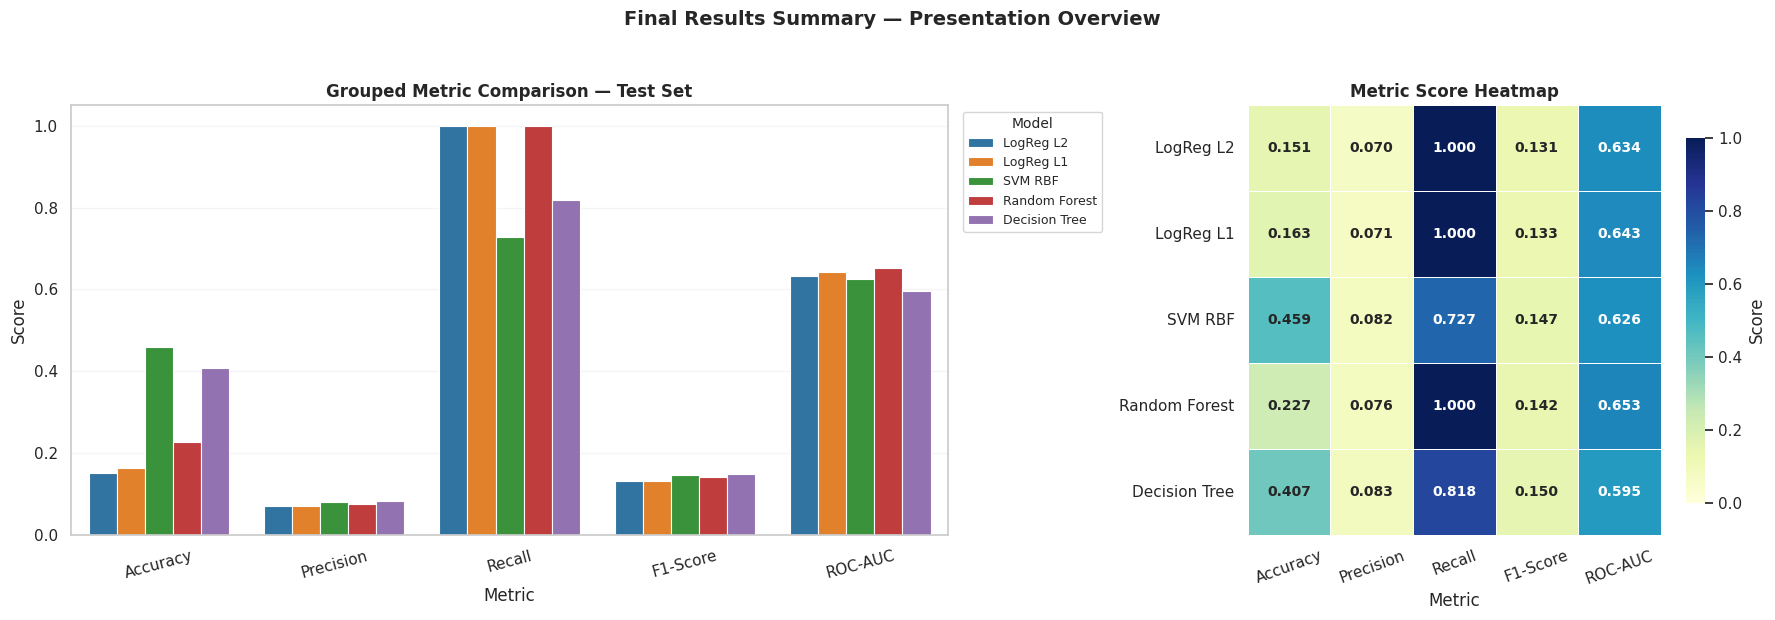

In [30]:
results = []
results.append(evaluate_model("LogReg L2",     log_reg_l2, X_train_scaled, X_test_scaled,
                               y_train, y_test, X_raw=X_train_raw, y_raw=y_train_raw))
results.append(evaluate_model("LogReg L1",     log_reg_l1, X_train_scaled, X_test_scaled,
                               y_train, y_test, X_raw=X_train_raw, y_raw=y_train_raw))
results.append(evaluate_model("SVM RBF",       svm_clf,    X_train_scaled, X_test_scaled,
                               y_train, y_test, X_raw=X_train_raw, y_raw=y_train_raw))
results.append(evaluate_model("Random Forest", rf_clf,     X_train_scaled, X_test_scaled,
                               y_train, y_test, X_raw=X_train_raw, y_raw=y_train_raw))
results.append(evaluate_model("Decision Tree", dt_clf,     X_train_scaled, X_test_scaled,
                               y_train, y_test, X_raw=X_train_raw, y_raw=y_train_raw))

results_df = pd.DataFrame(results)
display_cols = ["Model","Train Acc","Test Acc","Precision","Recall","F1-Score","AUC-ROC"]
summary_table = results_df[display_cols].round(4)

print("\n\nFinal Results Summary:")
print(summary_table.to_string(index=False))

from IPython.display import display
display(summary_table)

metrics_to_plot = ["Test Acc", "Precision", "Recall", "F1-Score", "AUC-ROC"]
metric_labels = {
    "Test Acc": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1-Score": "F1-Score",
    "AUC-ROC": "ROC-AUC",
}
summary_plot_df = results_df[["Model"] + metrics_to_plot].rename(columns=metric_labels)
summary_melted = summary_plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
summary_palette = dict(zip(summary_plot_df["Model"], sns.color_palette("tab10", len(summary_plot_df))))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.7, 1]})

sns.barplot(
    data=summary_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=summary_palette,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Grouped Metric Comparison — Test Set", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.2)
axes[0].set_axisbelow(True)
axes[0].legend(
    title="Model",
    fontsize=9,
    title_fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
)

sns.heatmap(
    summary_plot_df.set_index("Model"),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor="white",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Score", "shrink": 0.85},
    annot_kws={"size": 10, "weight": "bold"},
    ax=axes[1],
)
axes[1].set_title("Metric Score Heatmap", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].tick_params(axis="y", rotation=0)

fig.suptitle("Final Results Summary — Presentation Overview", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


### 6.3 All confusion matrices — side by side

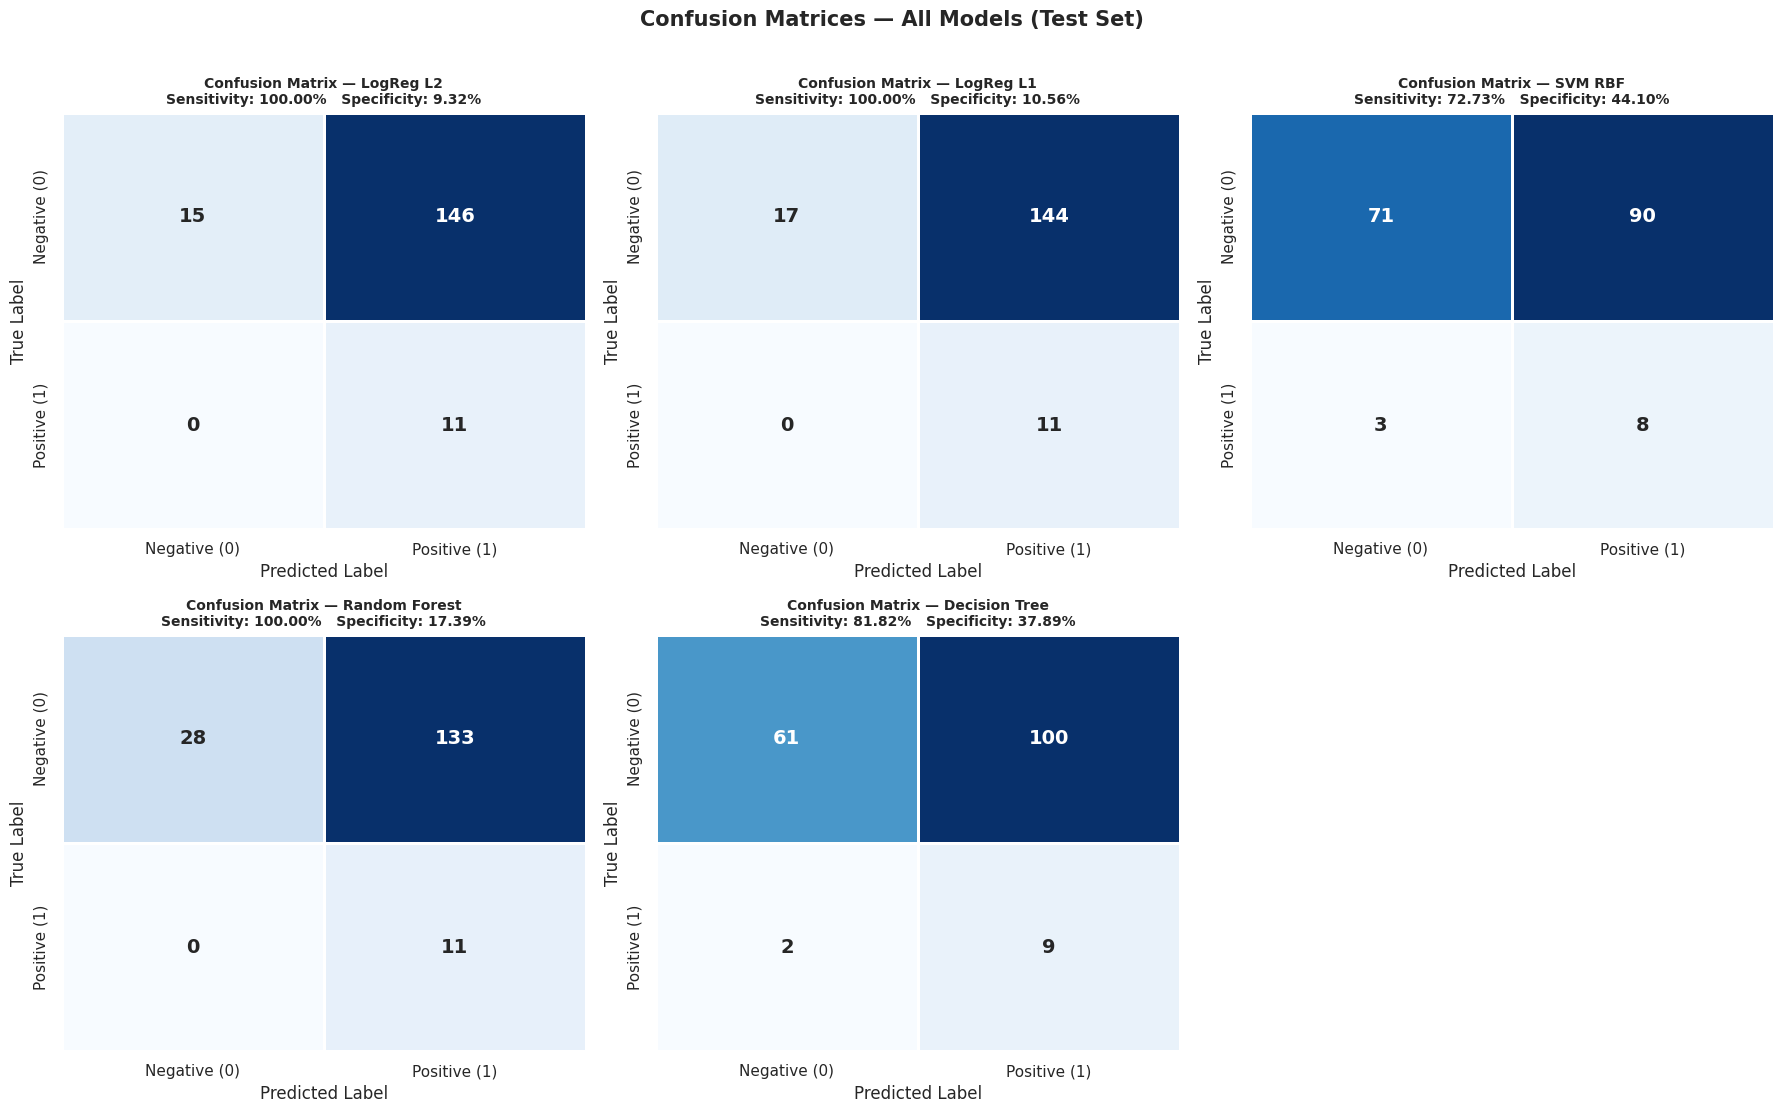

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()
for i, row in results_df.iterrows():
    cm = confusion_matrix(y_test, row["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative (0)","Positive (1)"],
                yticklabels=["Negative (0)","Positive (1)"],
                ax=axes_flat[i], linewidths=1, linecolor="white",
                cbar=False, annot_kws={"size":14,"weight":"bold"})
    sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
    axes_flat[i].set_title(f"Confusion Matrix — {row['Model']}\n"
                            f"Sensitivity: {sens:.2%}   Specificity: {spec:.2%}",
                            fontsize=10, fontweight="bold")
    axes_flat[i].set_ylabel("True Label"); axes_flat[i].set_xlabel("Predicted Label")
axes_flat[-1].set_visible(False)
fig.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Graphical comparison

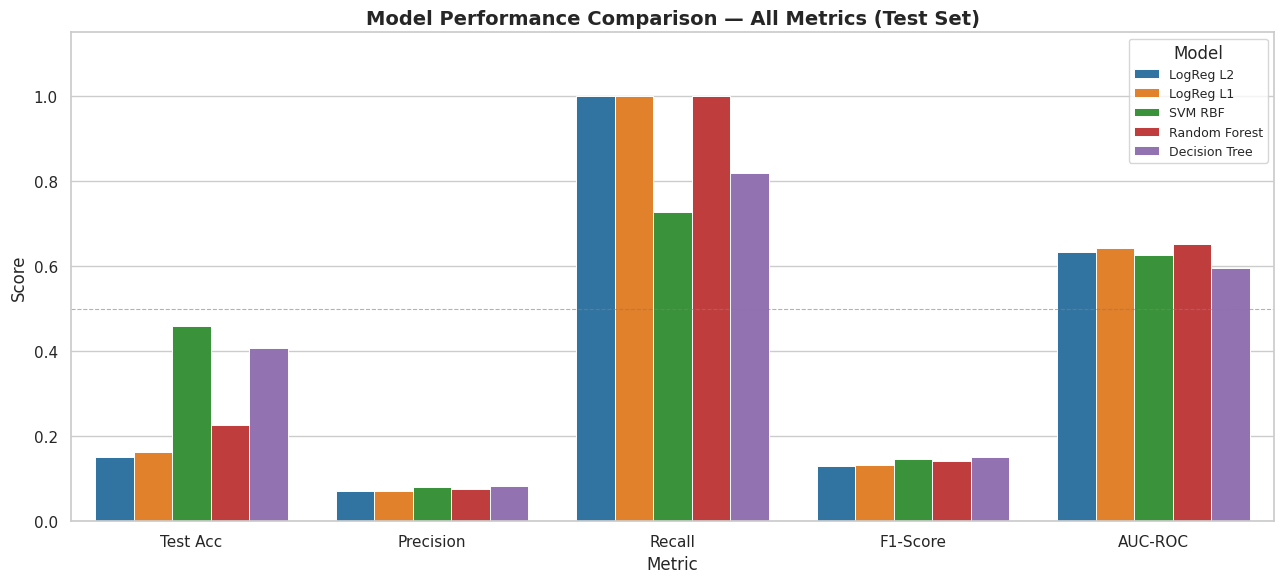

In [32]:
# Bar chart comparison
metrics_to_plot = ["Test Acc","Precision","Recall","F1-Score","AUC-ROC"]
plot_df = results_df[["Model"]+metrics_to_plot].melt(
    id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model",
            palette="tab10", edgecolor="white", linewidth=0.7)
plt.ylim(0, 1.15)
plt.title("Model Performance Comparison — All Metrics (Test Set)",
          fontsize=14, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("Metric")
plt.legend(title="Model", fontsize=9)
plt.axhline(0.5, color="grey", ls="--", lw=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

### 6.5 ROC Curves

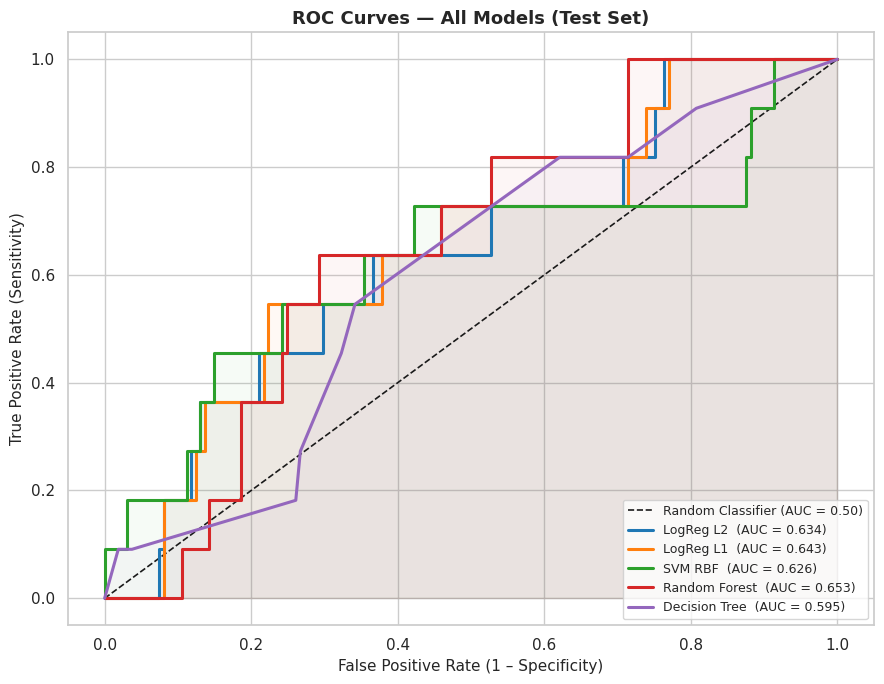

In [33]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1],[0,1],"k--",lw=1.2, label="Random Classifier (AUC = 0.50)")
palette_roc = sns.color_palette("tab10", len(results_df))
for i, row in results_df.iterrows():
    fpr, tpr, _ = roc_curve(y_test, row["y_prob"])
    ax.plot(fpr, tpr, lw=2.2, color=palette_roc[i],
            label=f"{row['Model']}  (AUC = {row['AUC-ROC']:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.04, color=palette_roc[i])
ax.set_xlabel("False Positive Rate (1 – Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax.set_title("ROC Curves — All Models (Test Set)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.6 Precision–Recall Curves

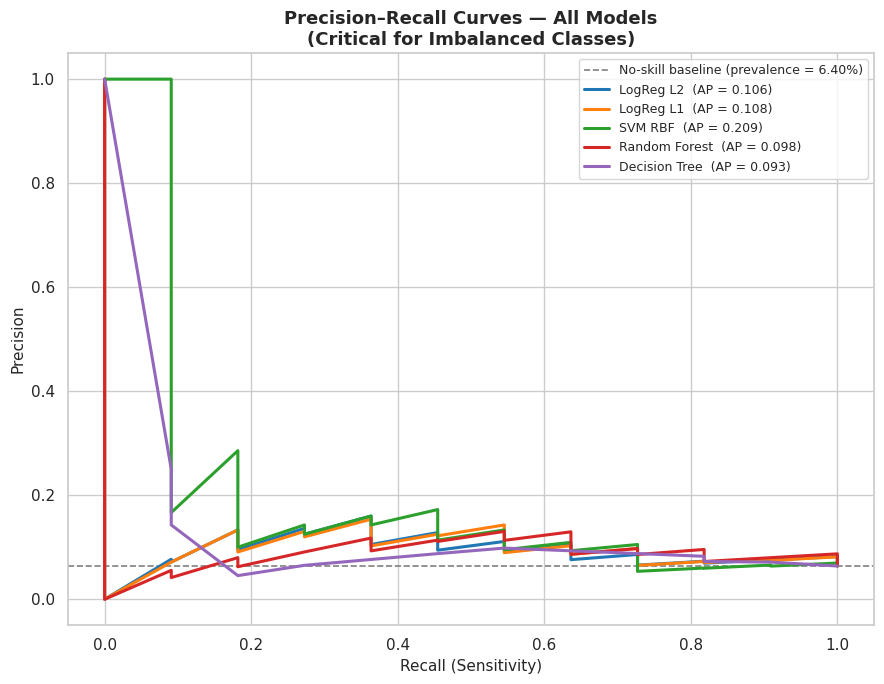

In [34]:
fig, ax = plt.subplots(figsize=(9, 7))
baseline = y_test.mean()
ax.axhline(baseline, ls="--", color="grey", lw=1.2,
           label=f"No-skill baseline (prevalence = {baseline:.2%})")
for i, row in results_df.iterrows():
    prec_c, rec_c, _ = precision_recall_curve(y_test, row["y_prob"])
    ap = average_precision_score(y_test, row["y_prob"])
    ax.plot(rec_c, prec_c, lw=2.2, color=palette_roc[i],
            label=f"{row['Model']}  (AP = {ap:.3f})")
ax.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–Recall Curves — All Models\n(Critical for Imbalanced Classes)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.7 Feature Importance — Random Forest

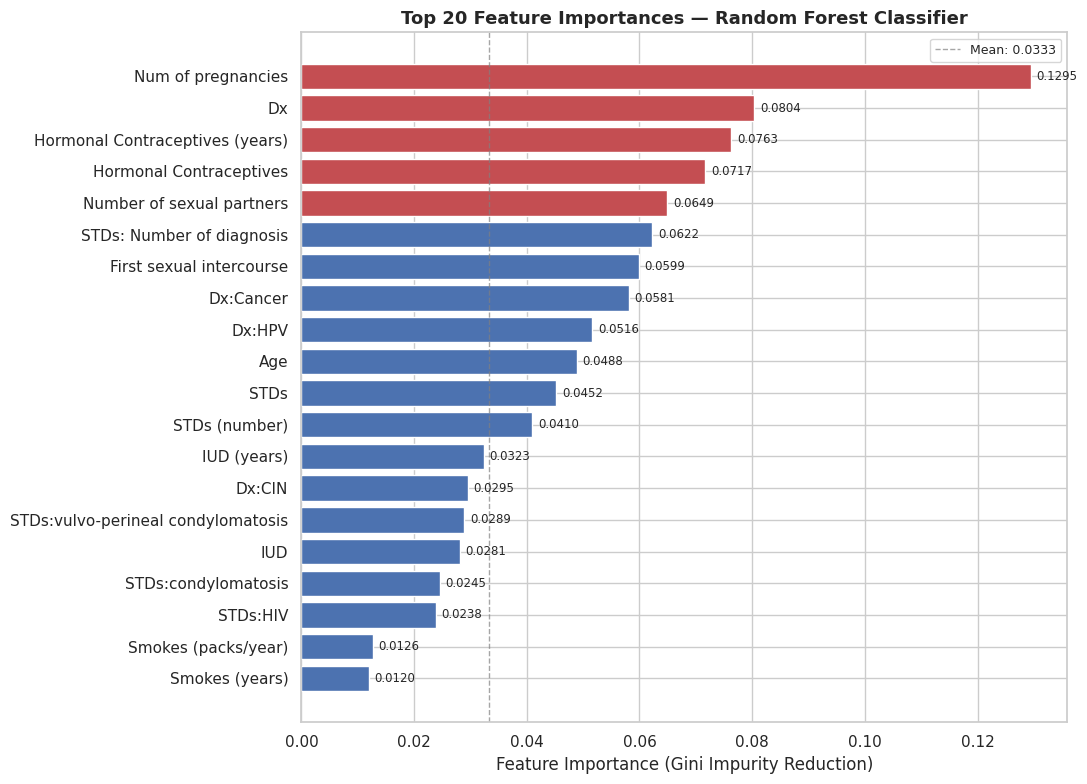


Top 10 features by Random Forest importance:
Num of pregnancies                 0.1295
Dx                                 0.0804
Hormonal Contraceptives (years)    0.0763
Hormonal Contraceptives            0.0717
Number of sexual partners          0.0649
STDs: Number of diagnosis          0.0622
First sexual intercourse           0.0599
Dx:Cancer                          0.0581
Dx:HPV                             0.0516
Age                                0.0488


In [35]:
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
top20 = feat_imp.tail(20)

plt.figure(figsize=(11, 8))
colors_imp = ["#C44E52" if v > feat_imp.quantile(0.85) else "#4C72B0" for v in top20.values]
bars = plt.barh(top20.index, top20.values, color=colors_imp, edgecolor="white")
plt.xlabel("Feature Importance (Gini Impurity Reduction)")
plt.title("Top 20 Feature Importances — Random Forest Classifier",
          fontsize=13, fontweight="bold")
for bar, v in zip(bars, top20.values):
    plt.text(v+0.001, bar.get_y()+bar.get_height()/2,
             f"{v:.4f}", va="center", fontsize=8.5)
plt.axvline(feat_imp.mean(), color="grey", ls="--", lw=1.0, alpha=0.7,
            label=f"Mean: {feat_imp.mean():.4f}")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features by Random Forest importance:")
print(feat_imp[::-1].head(10).round(4).to_string())

## 7. L1 vs L2 Regularization Analysis

**Goal of this section:** show how **L1** and **L2** regularization change the Logistic Regression model.

**How to read this section:**
- **L1 / Lasso** tends to push weak coefficients all the way to **zero**
- **L2 / Ridge** keeps most coefficients but **shrinks** them
- Smaller `C` means **stronger regularization**
- Larger `C` means **weaker regularization**

This section is useful because it shows whether the dataset is better explained by:
- a **smaller set of strong features** (L1), or
- a **broader set of moderate features** (L2)


In [36]:
# Extract and compare coefficients
coef_l2 = log_reg_l2.coef_[0]
coef_l1 = log_reg_l1.coef_[0]

nz_l2 = int(np.sum(coef_l2 != 0))
nz_l1 = int(np.sum(coef_l1 != 0))

print(f"Total features          : {len(FEATURES)}")
print(f"Non-zero coefs — L2     : {nz_l2}  ({nz_l2/len(FEATURES)*100:.0f}%)")
print(f"Non-zero coefs — L1     : {nz_l1}  ({nz_l1/len(FEATURES)*100:.0f}%)")
print(f"Features zeroed by L1   : {len(FEATURES)-nz_l1}")

coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coef L2": coef_l2, "Coef L1": coef_l1,
    "|Coef| L2": np.abs(coef_l2), "|Coef| L1": np.abs(coef_l1),
}).sort_values("|Coef| L1", ascending=False)

print("\nTop 10 features by |L1 coefficient|:")
print(coef_df[["Feature","|Coef| L1","|Coef| L2"]].head(10).round(4).to_string(index=False))

Total features          : 30
Non-zero coefs — L2     : 27  (90%)
Non-zero coefs — L1     : 24  (80%)
Features zeroed by L1   : 6

Top 10 features by |L1 coefficient|:
                           Feature  |Coef| L1  |Coef| L2
                     STDs:syphilis     0.7281     0.8463
                            Dx:CIN     0.7078     0.9692
                            Dx:HPV     0.4254     0.5102
                         Dx:Cancer     0.4200     0.6271
         STDs: Number of diagnosis     0.3678     0.4001
STDs:vulvo-perineal condylomatosis     0.3163     0.1768
   Hormonal Contraceptives (years)     0.2694     0.2707
                          STDs:HPV     0.2644     0.3638
           Hormonal Contraceptives     0.2295     0.2431
                          STDs:HIV     0.2287     0.2347


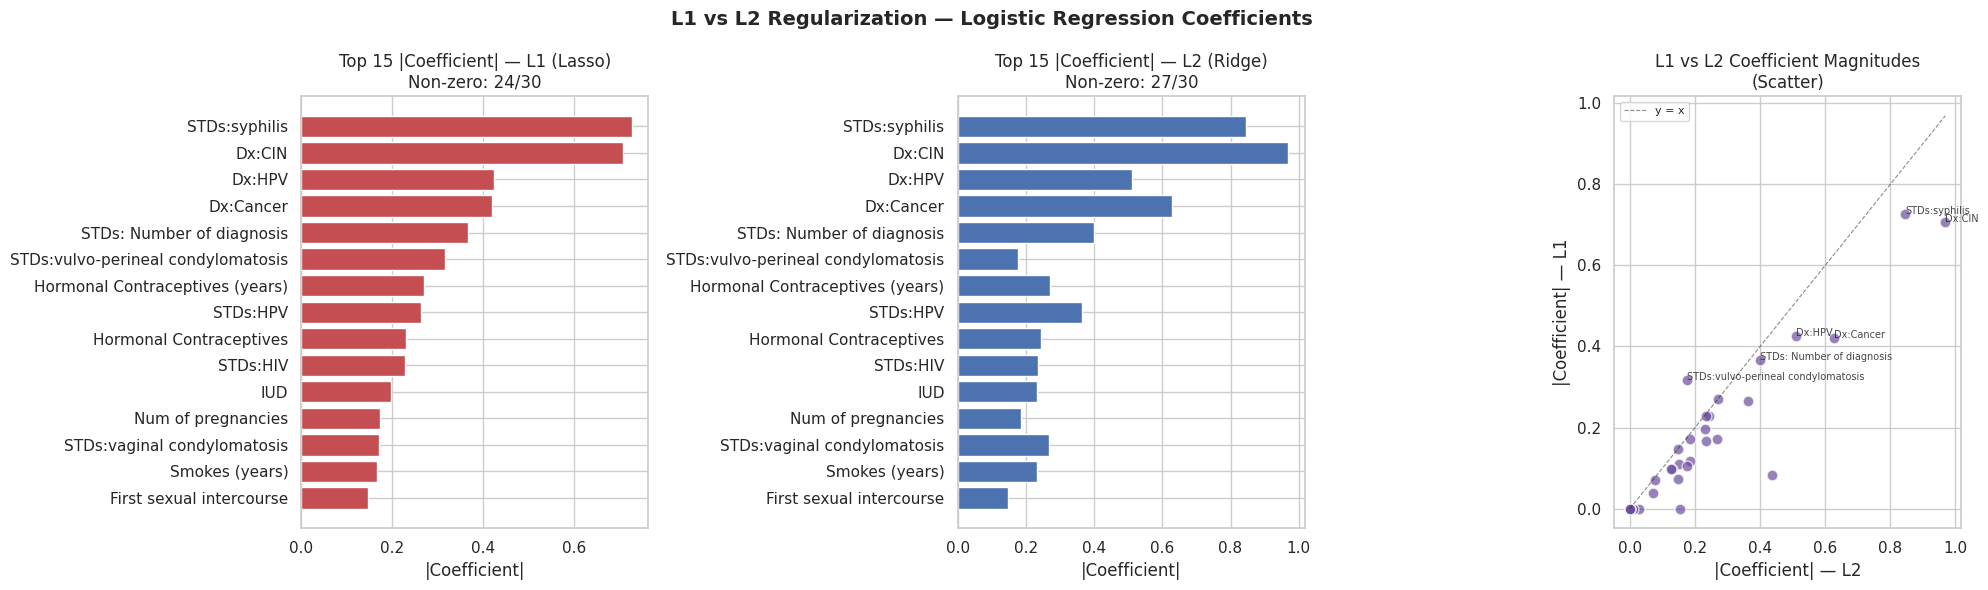

In [37]:
# Coefficient comparison visualization
top15 = coef_df.head(15)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("L1 vs L2 Regularization — Logistic Regression Coefficients",
             fontsize=14, fontweight="bold")

# L1 bar
axes[0].barh(top15["Feature"][::-1], top15["|Coef| L1"][::-1],
              color="#C44E52", edgecolor="white")
axes[0].set_title(f"Top 15 |Coefficient| — L1 (Lasso)\nNon-zero: {nz_l1}/{len(FEATURES)}")
axes[0].set_xlabel("|Coefficient|")

# L2 bar
axes[1].barh(top15["Feature"][::-1], top15["|Coef| L2"][::-1],
              color="#4C72B0", edgecolor="white")
axes[1].set_title(f"Top 15 |Coefficient| — L2 (Ridge)\nNon-zero: {nz_l2}/{len(FEATURES)}")
axes[1].set_xlabel("|Coefficient|")

# Scatter comparison
axes[2].scatter(coef_df["|Coef| L2"], coef_df["|Coef| L1"],
                alpha=0.7, s=60, color="#6A4C9C", edgecolors="white")
for _, row in coef_df.head(6).iterrows():
    axes[2].annotate(row["Feature"], (row["|Coef| L2"], row["|Coef| L1"]),
                     fontsize=7, alpha=0.85)
axes[2].plot([0, coef_df["|Coef| L2"].max()],
             [0, coef_df["|Coef| L2"].max()], "k--", lw=0.8, alpha=0.5, label="y = x")
axes[2].set_xlabel("|Coefficient| — L2"); axes[2].set_ylabel("|Coefficient| — L1")
axes[2].set_title("L1 vs L2 Coefficient Magnitudes\n(Scatter)")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

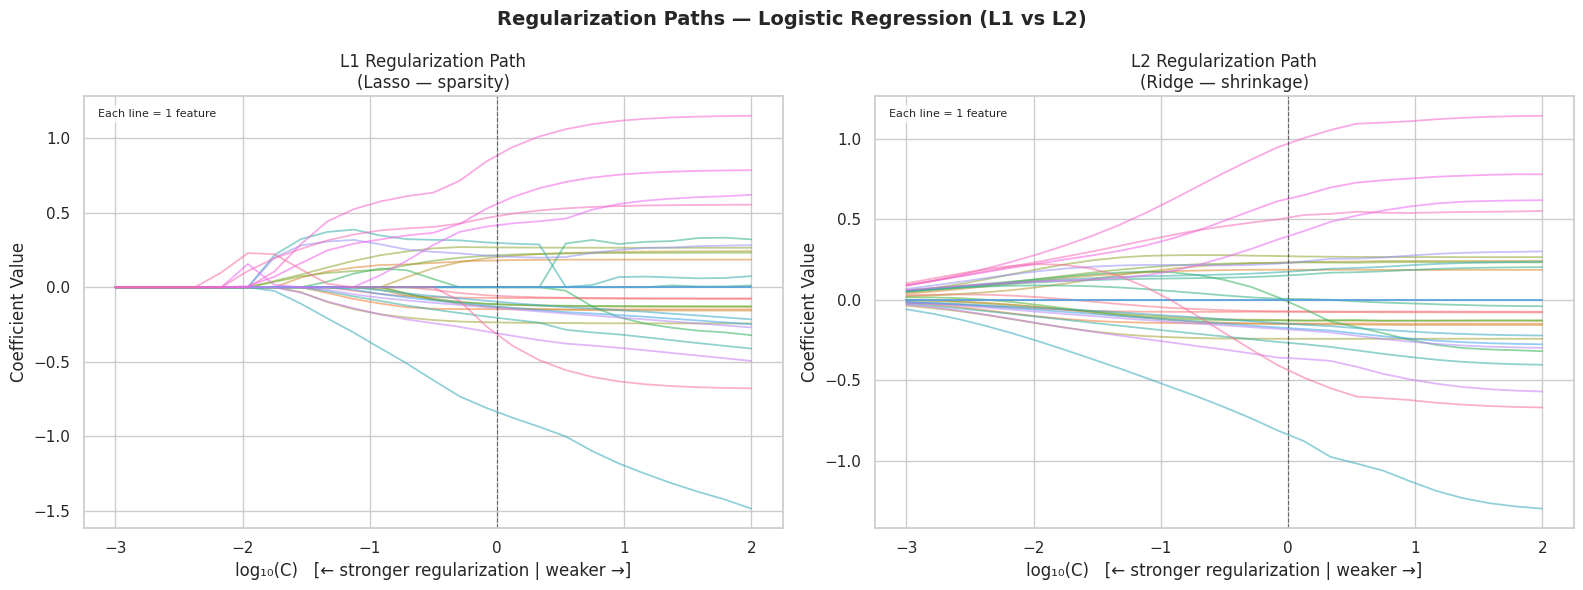

In [38]:
# Regularization paths — vary C and track coefficient values
import numpy as np
C_values = np.logspace(-3, 2, 25)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Regularization Paths — Logistic Regression (L1 vs L2)", fontsize=14, fontweight="bold")

for ax, (pen, solv) in zip(axes, [("l1","liblinear"),("l2","lbfgs")]):
    paths = []
    for C in C_values:
        lr = LogisticRegression(penalty=pen, C=C, solver=solv, max_iter=2000,
                                class_weight="balanced", random_state=42)
        lr.fit(X_train_scaled, y_train)
        paths.append(lr.coef_[0].copy())
    path_arr = np.array(paths)
    palette_path = sns.color_palette("husl", path_arr.shape[1])
    for j in range(path_arr.shape[1]):
        ax.plot(np.log10(C_values), path_arr[:, j], alpha=0.55, lw=1.3,
                color=palette_path[j % len(palette_path)])
    ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax.set_xlabel("log₁₀(C)   [← stronger regularization | weaker →]")
    ax.set_ylabel("Coefficient Value")
    lbl = "Lasso — sparsity" if pen=="l1" else "Ridge — shrinkage"
    ax.set_title(f"{pen.upper()} Regularization Path\n({lbl})")
    ax.text(0.02, 0.97, f"Each line = 1 feature",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox={"boxstyle":"round,pad=0.3","facecolor":"white","alpha":0.7})
plt.tight_layout()
plt.show()

**Summary of L1 vs L2 effects:**
- **L1** produces the **sparser** model and removes some weaker features completely
- **L2** keeps more features active, but with smaller weights
- The strongest diagnosis- and STD-related variables remain important under both penalties
- This supports keeping **Logistic Regression** as a strong, explainable baseline


## 8. Learning Curves — Bias / Variance Analysis

**Goal of this section:** check how each model behaves as the training size grows.

**What we look for:**
- whether the model is **overfitting**
- whether it is **underfitting**
- whether train and validation performance are moving closer together
- whether more data is still helping

> These curves are useful because one final score alone does not tell us **how** the model is learning.


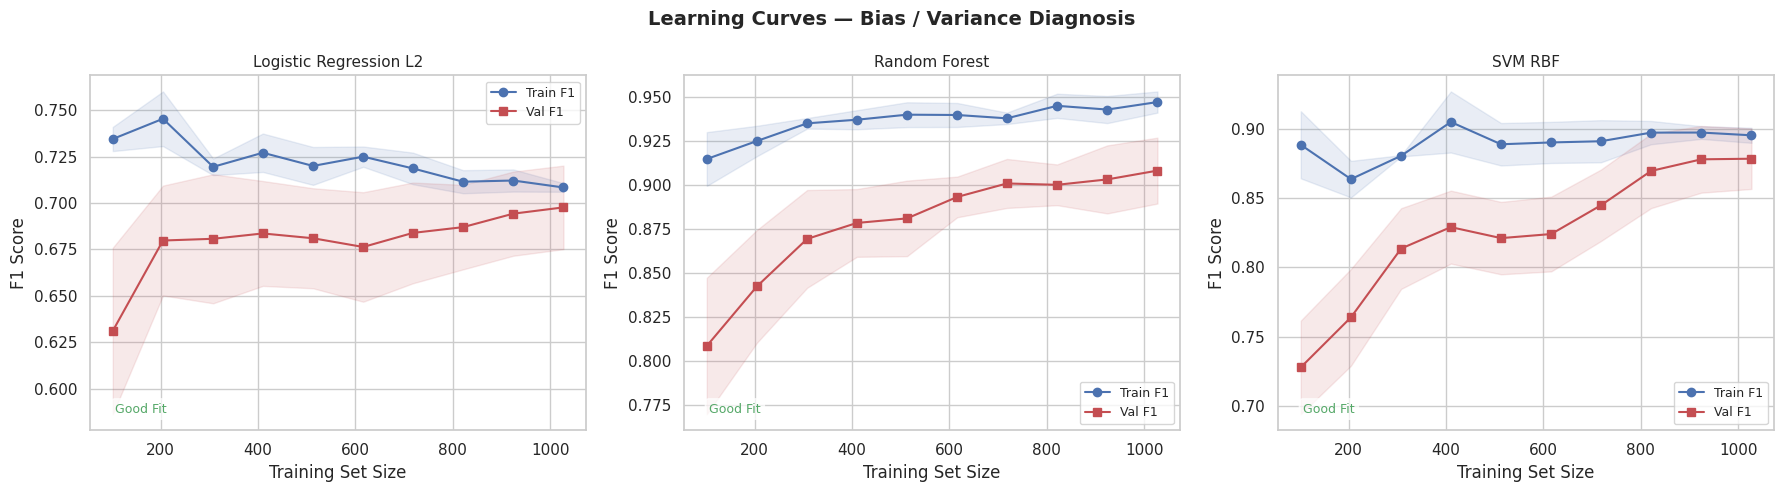

In [39]:
lc_models = [
    ("Logistic Regression L2", log_reg_l2),
    ("Random Forest",          rf_clf),
    ("SVM RBF",                svm_clf),
]
train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Learning Curves — Bias / Variance Diagnosis", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, lc_models):
    ts, tr_sc, val_sc = learning_curve(
        model, X_train_scaled, y_train,
        train_sizes=train_sizes, cv=5, scoring="f1", n_jobs=-1)
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    vl_m, vl_s = val_sc.mean(1), val_sc.std(1)
    ax.plot(ts, tr_m, "o-", color="#4C72B0", label="Train F1")
    ax.plot(ts, vl_m, "s-", color="#C44E52", label="Val F1")
    ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color="#4C72B0")
    ax.fill_between(ts, vl_m-vl_s, vl_m+vl_s, alpha=0.12, color="#C44E52")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Training Set Size"); ax.set_ylabel("F1 Score")
    ax.legend(fontsize=9)
    gap = tr_m[-1] - vl_m[-1]
    diag = "High Variance" if gap > 0.1 else "High Bias" if vl_m[-1] < 0.4 else "Good Fit"
    ax.text(0.05, 0.05, diag, transform=ax.transAxes, fontsize=9,
            color="#C44E52" if diag!="Good Fit" else "#55A868",
            bbox={"boxstyle":"round","facecolor":"white","alpha":0.7})
plt.tight_layout()
plt.show()

## 9. Final Scorecard

This section gives a compact summary of the final model comparison.

**How to read it:**
- the **heatmap** makes it easy to compare models side by side
- the **radar chart** shows each model's performance shape across all major metrics
- together, they help us see which model is the best balance for this dataset


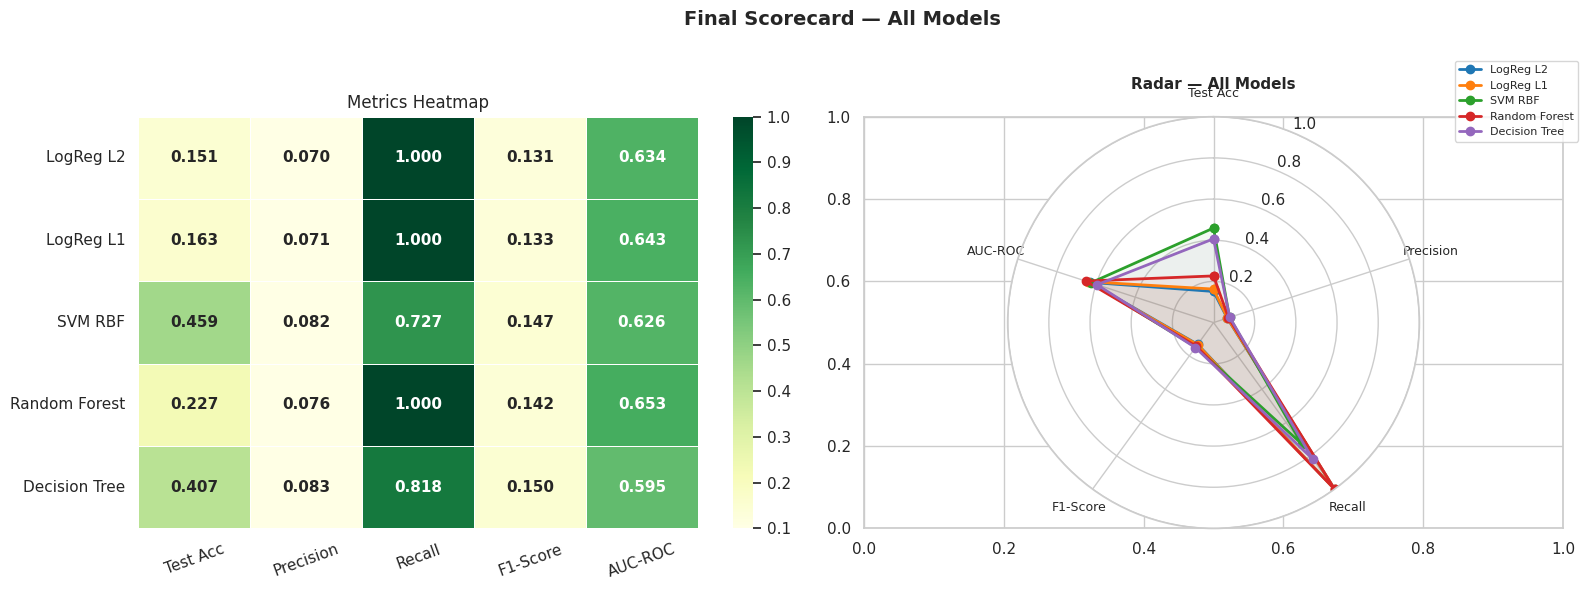

In [40]:
# Heatmap + Radar
import numpy as np
score_cols = ["Test Acc","Precision","Recall","F1-Score","AUC-ROC"]
score_mat  = results_df[score_cols].values
model_names = results_df["Model"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Final Scorecard — All Models", fontsize=14, fontweight="bold")

sns.heatmap(score_mat, annot=True, fmt=".3f", cmap="YlGn",
            xticklabels=score_cols, yticklabels=model_names,
            linewidths=0.5, linecolor="white", vmin=0.1, vmax=1.0,
            ax=axes[0], annot_kws={"size":11,"weight":"bold"})
axes[0].set_title("Metrics Heatmap")
axes[0].tick_params(axis="x", rotation=20); axes[0].tick_params(axis="y", rotation=0)

angles = np.linspace(0, 2*np.pi, len(score_cols), endpoint=False).tolist()
angles += angles[:1]
ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi/2); ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(score_cols, fontsize=9)
ax2.set_ylim(0, 1); ax2.set_title("Radar — All Models", pad=20, fontsize=11, fontweight="bold")
pal_r = sns.color_palette("tab10", len(model_names))
for i, (name, row) in enumerate(zip(model_names, score_mat)):
    vals = list(row) + [row[0]]
    ax2.plot(angles, vals, "o-", lw=2, color=pal_r[i], label=name)
    ax2.fill(angles, vals, alpha=0.06, color=pal_r[i])
ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

## 10. Summary & Observations

### Data Acquisition and Preparation
- The dataset contains **858 patients** and **36 original features**
- Missing values were loaded correctly by treating **`?` as `NaN`**
- We removed **2 near-empty columns** and **3 leaky diagnostic-test columns**
- The target is highly imbalanced, so we treated that as a core modeling issue from the start

### Exploratory Data Analysis
- The target distribution confirmed a **strong class imbalance**
- Histograms, KDE plots, and boxplots showed that many features are **skewed** and **zero-heavy**
- Correlation and prevalence charts showed that several **diagnosis-** and **STD-related** variables carry useful signal
- Scatter plots and pair plots showed that the classes are **not cleanly separable** with simple linear rules

### Preprocessing & Regularization
- We used **median imputation** because it is more robust than the mean for skewed data
- We used **StandardScaler** so scale-sensitive models like Logistic Regression and SVM can train fairly
- We handled the minority class with **SMOTE on the training set only**
- We compared **L1** and **L2** regularization to see whether the model prefers sparsity or smooth shrinkage

### Model Selection & Evaluation
- We kept **Logistic Regression** as the main explainable baseline
- We compared it with **SVM RBF**, **Random Forest**, and **Decision Tree**
- We did **not** add hyperparameter tuning here; the goal was a clean, interpretable comparison
- We used **threshold tuning** so the models were not judged only at the default 0.50 cutoff
- We reported **Precision**, **Recall**, **F1-score**, **ROC-AUC**, plus **ROC** and **Precision–Recall** curves

### Main takeaway
- This is a hard, imbalanced medical classification problem
- No single feature solves it on its own
- The project now has a stronger imbalance-handling and evaluation story than the original version
- The clearest strengths of the notebook are: **data cleaning**, **EDA**, **regularization analysis**, and **model comparison**
